In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())
from datetime import datetime
import datetime as dt

from siphon.catalog import TDSCatalog
#from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indicators as xci

# pysal.esda for spatial autocorrelation analysis
import esda 
import libpysal as lps

D:\anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
# change working directory
os.chdir('D:/UofG/Arctic-VBD')
print(os.getcwd()) # verify change

D:\UofG\Arctic-VBD


# 1. Function for calculating suitability for nematode transmission

In [3]:
# Load the csv file containing suitability at each temperature
suitability = pd.read_csv("data-processed/S.output.lowerCI.csv")
suitability = suitability[["temp", "scaled_lowerCI"]]
suitability[suitability['scaled_lowerCI'] > 0.001]

,temp,scaled_lowerCI
172,17.2,0.001190
173,17.3,0.002582
174,17.4,0.004929
175,17.5,0.008146
176,17.6,0.012799
...,...,...
257,25.7,0.152067
258,25.8,0.099720
259,25.9,0.053234
260,26.0,0.018027


In [4]:
suitability[suitability['scaled_lowerCI'] > 0.5]

,temp,scaled_lowerCI
204,20.4,0.511214
205,20.5,0.537549
206,20.6,0.561129
207,20.7,0.588186
208,20.8,0.614855
209,20.9,0.641609
210,21.0,0.672958
211,21.1,0.700382
212,21.2,0.725005
213,21.3,0.753908


In [5]:
# Create an interpolation function such that the suitability of any temperature can be calculated (even if it is not in the csv file)

from scipy.interpolate import interp1d
suit_func = interp1d(suitability["temp"], suitability["scaled_lowerCI"], 
                     bounds_error=False, fill_value=0)
suit_func

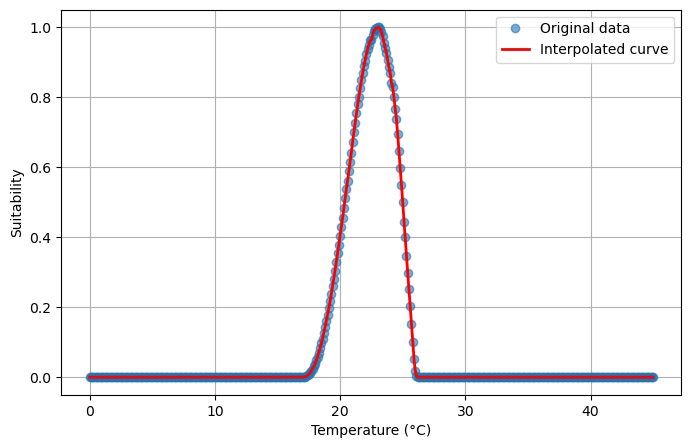

In [6]:
# Check the interpolation function
temps = np.linspace(suitability["temp"].min(), suitability["temp"].max(), 1000)

plt.figure(figsize = (8,5))
plt.plot(suitability["temp"], suitability["scaled_lowerCI"], 'o', label="Original data", alpha=0.6)
plt.plot(temps, suit_func(temps), '-', label = "Interpolated curve", color='red', linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Suitability")
plt.legend()
plt.grid(True)
plt.show()

Below are some functions to calculate thermal suitability and to test whether mean changes are significant. The first function, effective_sample_size, calculates the effective sample size to account for non-independence between serially correlated data points. The second function, get_suitability, calculates the number of days that S(T) > 0.001 for each grid cell in each year, as well as some summary statistics for significance testing.

In [7]:
# function for calculating effective sample size. Code adapted from https://utcdw.physics.utoronto.ca/UTCDW_Guidebook/Chapter3/section3.4_climate_model_output_from_ESGF.html
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

In [8]:
def get_suitability(data, thres = 0.001):
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])
    
    # Get effective sample size for each period, for significance testing later on
    #neff = effective_sample_size(S)

    # Count the number of days where S > thres in each year
    S = S.where(~np.isnan(data.tas))
    
    suit_days = S > thres
    days_per_year = suit_days.groupby("time.year").sum(dim = "time")

    # Keep land mask
    mask = data.tas.isel(time=0).isnull()
    days_per_year = days_per_year.where(~mask)
    
    # Summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    suit_days_mean = days_per_year.mean('year') # Calculate the mean # of days where S across the whole period
    suit_days_std = days_per_year.std('year') #Standard deviation
    
    ds_out = xr.Dataset({'mean': suit_days_mean, 
                         'std': suit_days_std
                         #'neff': neff
                        })
    
    return ds_out

In [8]:
def suitability(data, thres = 0.001):

    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])

    # Count the number of days where S > thres in each year:
    S = S.where(~np.isnan(data.tas))
    suit_days = S > thres

    # Number of suitable days
    n_days = suit_days.groupby("time.year").sum("time")
    

    # Land mask
    land_mask = ~data.tas.isel(time=0).isnull()
    n_days = n_days.where(land_mask)
    
    return xr.Dataset({
        "n_days": n_days
    })

In [9]:
def suit_first_last_day(data, thres = 0.001):

    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])

    # Count the number of days where S > thres in each year:
    S = S.where(~np.isnan(data.tas))
    suit_days = S > thres

    # Number of suitable days
    n_days = suit_days.groupby("time.year").sum("time")
    
    # Find the first and last day of suitability:
    # Day of year
    doy = suit_days.time.dt.dayofyear

    # First suitable day
    first_day = doy.where(suit_days).groupby("time.year").min("time")

    # Last suitable day
    last_day = doy.where(suit_days).groupby("time.year").max("time")

    # Land mask
    land_mask = ~data.tas.isel(time=0).isnull()
    
    n_days = n_days.where(land_mask)
    first_day = first_day.where(land_mask)
    last_day = last_day.where(land_mask)
    
    return xr.Dataset({
        "n_days": n_days,
        "first_day": first_day,
        "last_day": last_day
    })

In [10]:
def summary(ds_yearly):
    
    # Summary statistics across the whole time period
    
    ds_out = xr.Dataset()

    for var in ds_yearly.data_vars:

        ds_out[f"{var}_med"] = ds_yearly[var].median("year", skipna=True)
        ds_out[f"{var}_mean"] = ds_yearly[var].mean("year")
        ds_out[f"{var}_std"] = ds_yearly[var].std("year")
        ds_out[f"{var}_q25"] = ds_yearly[var].quantile(0.25, dim="year")
        ds_out[f"{var}_q75"] = ds_yearly[var].quantile(0.75, dim="year")

    return ds_out

Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling.

In [ ]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

This time we will use CanESM5 ensemble member r1i1p2f1

## 2. SSP5-8.5

In [ ]:
ssp585_url = datasets_canesm_sds[11] #SSP5-8.5; ensemble member: r1i1p2f1
print(ssp585_url)
ssp585_all = xr.open_dataset(ssp585_url)[['tasmax','tasmin']]

In [ ]:
# select spatial domain (all of Canada)
# lat_bnds = [41, 90]
# lon_bnds = [-143, -52]

# select spatial domain (Down to central Manitoba)
#lat_bnds = [55, 90]
#lon_bnds = [-143, -59]


# select spatial domain
#ssp585 = ssp585_all.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))
ssp585 = ssp585_all

In [ ]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

lats = [CBAY_lat,KUG_lat, YKN_lat]
lons = [CBAY_lon, KUG_lon, YKN_lon]

ssp585 = ssp585_all.sel(
    lat= lats,
    lon= lons,
    method="nearest"
)

### 2a. Saving the climate data

We need daily mean temperature. However, this dataset only contains the daily maximum and daily minimum temperatures. To get the daily mean temperature, we will take the average of the daily maximum and daily minimum. Since the dataset is too large, we will subset the dataset by year and compute the mean temperature.

In [ ]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    # outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    outfile = f"tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1986
end_year = 1990

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    #outfile = f"tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1991
end_year = 1994

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    #outfile = f"tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2026
end_year = 2027

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585v_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2065
end_year = 2066

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp5855.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2067
end_year = 2069

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2070
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

### 2b. Calculate suitability

In [1]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

#### Historical 1: 1950-1980

##### S(T) > 0.001

In [50]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist1_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_hist1_low = summary(ssp585_hist1_low)

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\147065100.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist1_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [47]:
ssp585_hist1_low

<xarray.Dataset> Size: 13MB
Dimensions:      (lon: 984, lat: 342)
Coordinates:
  * lon          (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
  * lat          (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
    quantile     float64 8B 0.25
Data variables:
    n_days_med   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_mean  (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_std   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_q25   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_q75   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan

##### S(T) > 0.5

In [51]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist1_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_hist1_high = summary(ssp585_hist1_high)

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\223721696.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist1_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


#### Historical 2: 1995-2025

##### S(T) > 0.001

In [52]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist2_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_hist2_low = summary(ssp585_hist2_low)

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\1110309357.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist2_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [53]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist2_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_hist2_high = summary(ssp585_hist2_high)

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\1968619844.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist2_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


#### Future 1: 2030-2060

##### S(T) > 0.001

In [54]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future1_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp5855_future1_low = summary(ssp585_future1_low)

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\45643692.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future1_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [55]:
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future1_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_future1_high = summary(ssp585_future1_high)

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\2491541172.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future1_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


#### Future 2: 2700-2100

##### S(T) > 0.001

In [56]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future2_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_future2_low = summary(ssp585_future2_low)

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\2672259692.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future2_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [57]:
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future2_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp585_future2_high = summary(ssp585_future2_high)

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\4055964662.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future2_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


### 2c. Mapping

In [84]:
ssp585_future2_low['n_days_mean'].max()

<xarray.DataArray 'n_days_mean' ()> Size: 8B
array(107.06451613)
Coordinates:
    quantile  float64 8B 0.25
Attributes:
    units:          DegC
    standard_name:  air_temperature
    _ChunkSizes:    [1460   50   50]

#### Historical 1: 1950-1980

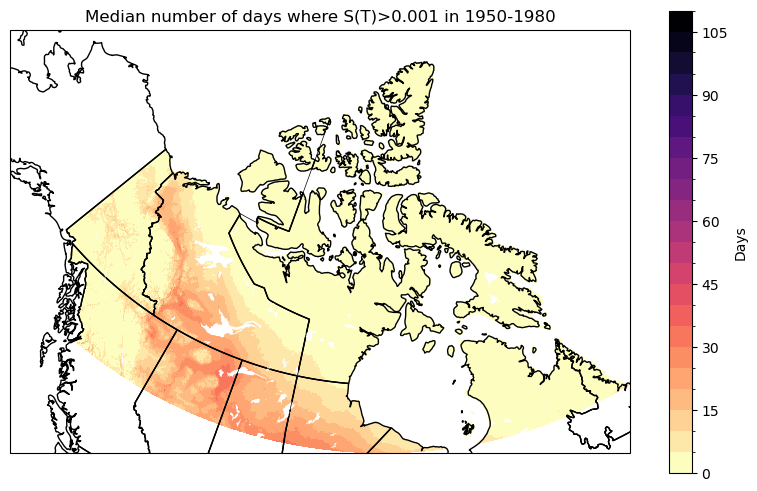

In [62]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp585_hist1_low['n_days_mean'].plot.pcolormesh(ax = ax, 
                                 transform = ccrs.PlateCarree(),
                                 levels = levels, 
                                 cmap = 'magma_r',
                                 cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Median number of days where S(T)>0.001 in 1950-1980")

plt.savefig("figures/S_0.001_1950-1980.png", dpi=300, bbox_inches="tight")
plt.show()

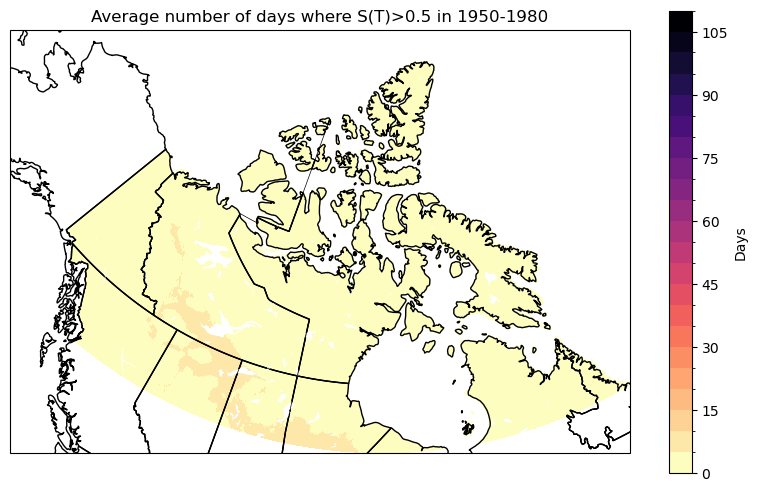

In [79]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_hist1_high['n_days_mean'].plot.pcolormesh(ax = ax, 
                                 transform = ccrs.PlateCarree(),
                                 levels = levels, 
                                 cmap = 'magma_r',
                                 cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.5 in 1950-1980")

plt.savefig("figures/S_0.5_1950-1980.png", dpi=300, bbox_inches="tight")
plt.show()

#### Historical 2: 1995-2025

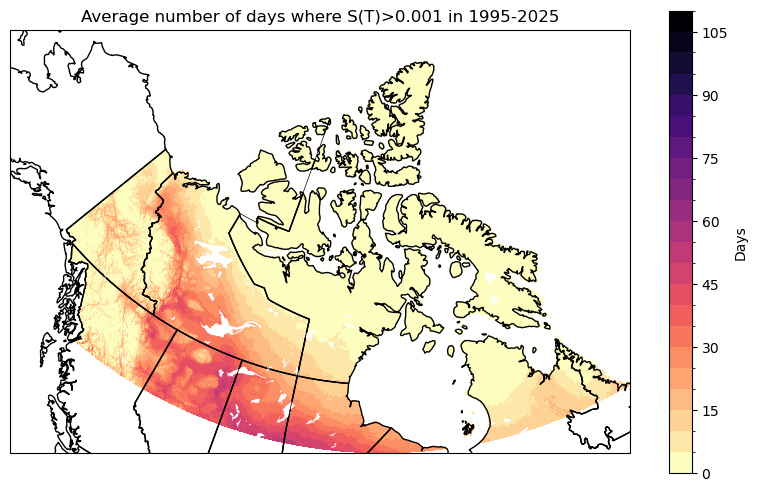

In [64]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_hist2_low["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = 'magma_r',
                                                cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                               )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 1995-2025")

plt.savefig("figures/S_0.001_1995-2025.png", dpi=300, bbox_inches="tight")

plt.show()

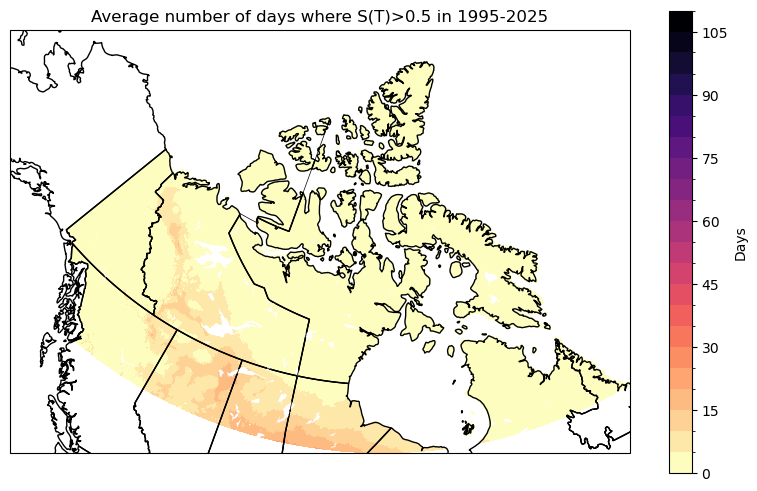

In [78]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_hist2_high["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                 transform = ccrs.PlateCarree(),
                                                 levels = levels, 
                                                 cmap = 'magma_r',
                                                 cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.5 in 1995-2025")

plt.savefig("figures/S_0.5_1995-2025.png", dpi=300, bbox_inches="tight")

plt.show()

#### Future 1: 2030-2060

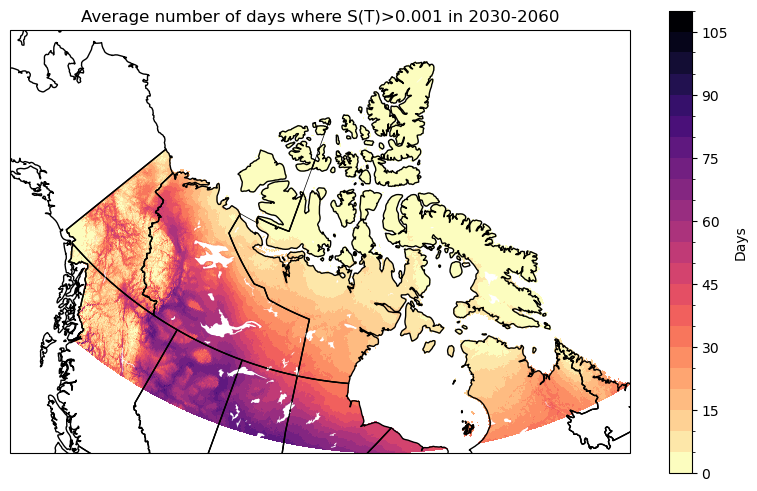

In [77]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_future1_low["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = 'magma_r',
                                                  cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                 )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 2030-2060")

plt.savefig("figures/S_0.001_2030-2060.png", dpi=300, bbox_inches="tight")

plt.show()

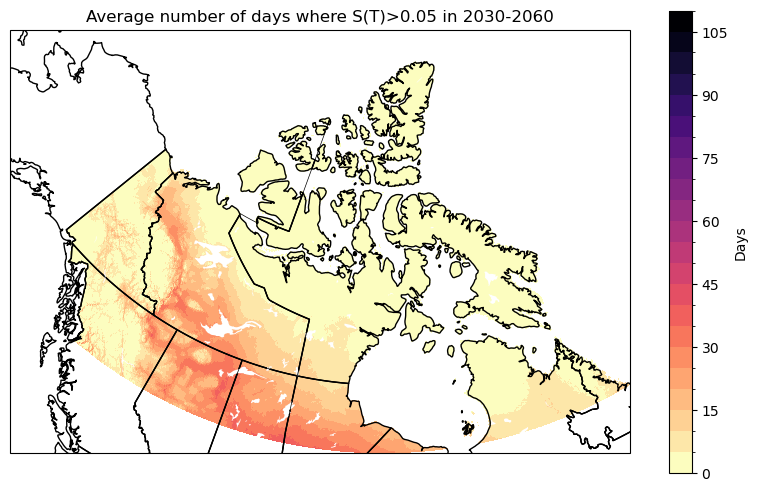

In [76]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_future1_high["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = 'magma_r',
                                                   cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                  )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.05 in 2030-2060")

plt.savefig("figures/S_0.05_2030-2060.png", dpi=300, bbox_inches="tight")

plt.show()

#### Future 2: 2070-2100

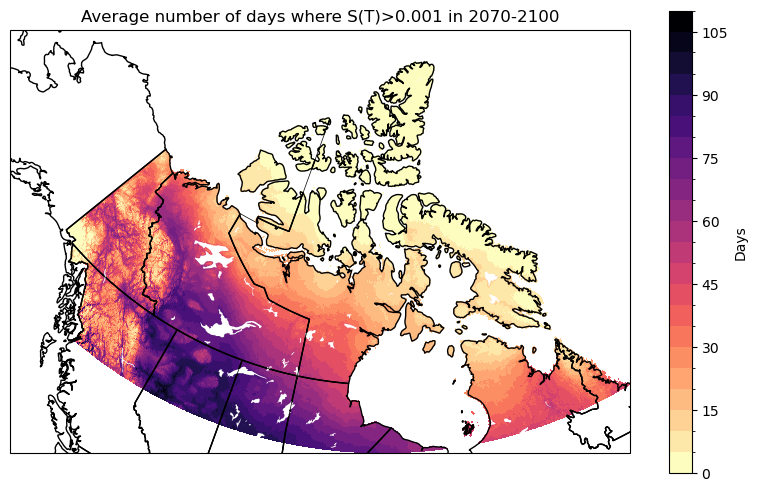

In [74]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_future2_low["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = 'magma_r',
                                                  cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                 )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 2070-2100")

plt.savefig("figures/S_0.001_2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

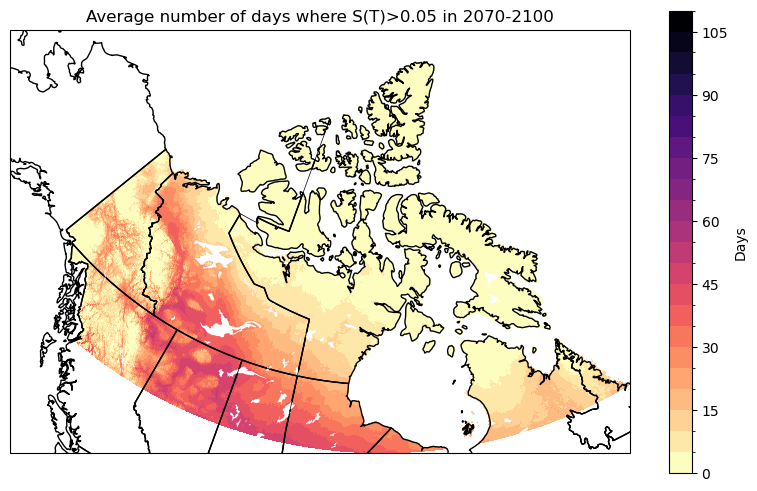

In [75]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_future2_high["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = 'magma_r',
                                                   cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                  )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.05 in 2070-2100")

plt.savefig("figures/S_0.05_2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

We will specifically look at the trends in 3 locations: Cambridge Bay, Kugluktuk, and Yellowknife

In [12]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

In [13]:
lats = [CBAY_lat, KUG_lat, YKN_lat]
lons = [CBAY_lon, KUG_lon, YKN_lon]

Plot maps that also show the three locations

In [97]:
ssp245_hist1_low = ssp245_hist1_low.drop_vars("quantile")
ssp245_hist1_high = ssp245_hist1_high .drop_vars("quantile")
ssp245_hist2_low = ssp245_hist2_low.drop_vars("quantile")
ssp245_hist2_high = ssp245_hist2_high .drop_vars("quantile")
ssp245_future1_low = ssp245_future1_low.drop_vars("quantile")
ssp245_future1_high = ssp245_future1_high .drop_vars("quantile")
ssp245_future2_low = ssp245_future2_low.drop_vars("quantile")
ssp245_future2_high = ssp245_future2_high .drop_vars("quantile")

C:\Users\tszyi\AppData\Local\Temp\ipykernel_2652\292574097.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


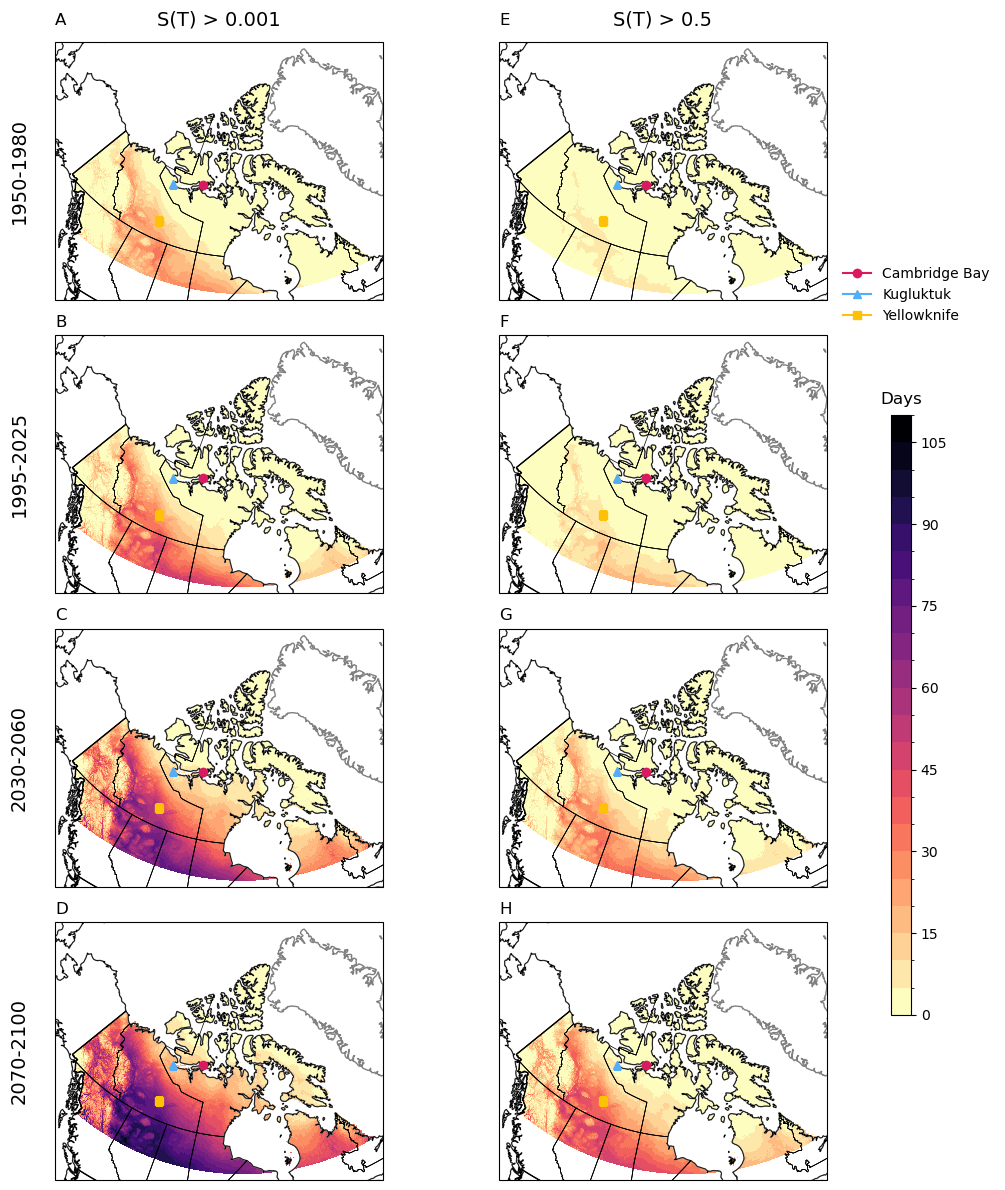

In [133]:
# plot all historical and future simulations
levels = np.arange(0, 115, 5)
cmap = 'magma_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 2, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980, S(T) > 0.001
ssp245_hist1_low["n_days_mean"].plot.pcolormesh(ax = axes[0,0], 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = cmap,
                                                add_colorbar = False
                                               )
axes[0,0].set_title("A", loc='left')

# Historical 1: 1950-1980, S(T) > 0.5
ssp245_hist1_high["n_days_mean"].plot.pcolormesh(ax = axes[0,1], 
                                                 transform = ccrs.PlateCarree(),
                                                 levels = levels, 
                                                 cmap = cmap,
                                                 add_colorbar = False
                                                )
axes[0,1].set_title("E", loc='left')

# Historical 2: 1995-2025, S(T) > 0.001
ssp245_hist2_low["n_days_mean"].plot.pcolormesh(ax = axes[1,0], 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = cmap,
                                                add_colorbar = False
                                               )
axes[1,0].set_title("B", loc='left')


# Historical 2: 1995-2025, S(T) > 0.5
ssp245_hist2_high["n_days_mean"].plot.pcolormesh(ax = axes[1,1], 
                                                 transform = ccrs.PlateCarree(),
                                                 levels = levels, 
                                                 cmap = cmap,
                                                 add_colorbar = False
                                                )
axes[1,1].set_title("F", loc='left')

# Future 1: 2030-2060, S(T) > 0.001
ssp245_future1_low["n_days_mean"].plot.pcolormesh(ax = axes[2,0],
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = cmap,
                                                  add_colorbar = False
                                                 )
axes[2,0].set_title("C", loc='left')


# Future 1: 2030-2060, S(T) > 0.5
ssp245_future1_high["n_days_mean"].plot.pcolormesh(ax = axes[2,1], 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = cmap,
                                                   add_colorbar = False
                                                  )
axes[2,1].set_title("G", loc='left')

# Future 2: 2070-2100, S(T) > 0.001
ssp245_future2_low["n_days_mean"].plot.pcolormesh(ax = axes[3,0],
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = cmap,
                                                  add_colorbar = False
                                                 )
axes[3,0].set_title("D", loc='left')


# Future 2: 2070-2100, S(T) > 0.5
pcm = ssp245_future2_high["n_days_mean"].plot.pcolormesh(ax = axes[3,1], 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = cmap,
                                                   add_colorbar = False
                                                  )
axes[3,1].set_title("H", loc='left')

for i, ax in enumerate(axes.flat): # flat makes axes 1D instead of 2D
    ax.plot(CBAY_lon, CBAY_lat, 
            marker = 'o', 
            color = '#D81B60', 
            transform=ccrs.PlateCarree(), 
            label='Cambridge Bay' if i == 0 else "") # Only the first subplot contributes to the legend 
    
    ax.plot(KUG_lon, KUG_lat, 
            marker = '^', 
            color = '#56ADF7', 
            transform=ccrs.PlateCarree(), 
            label = 'Kugluktuk' if i == 0 else "")
    
    ax.plot(YKN_lon, YKN_lat, 
            marker = 's', 
            color = '#FFC107', 
            transform=ccrs.PlateCarree(), 
            label = 'Yellowknife' if i == 0 else "")
    
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())

# Add colourbar 
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.5]) # colorbar axis

cbar = fig.colorbar(pcm, cax = cbar_ax)
cbar.ax.set_title("Days", pad=8, fontsize=12)

# Add legend
fig.legend(
    loc='center left',
    frameon=False,
    bbox_to_anchor=(0.89, 0.75)
)
# Column and row labels
cols = ["S(T) > 0.001", "S(T) > 0.5"]
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Column headers
for col, label in enumerate(cols):
    axes[0, col].set_title(label, fontsize=14, pad=12) # Add column 

# Row headers
for row, label in enumerate(rows):
    axes[row, 0].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row, 0].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/S_ssp245_lowerCI.png", dpi=300, bbox_inches="tight")

plt.show()

#### Cambridge Bay, Kugluktuk, and Yellowknife

Now we look at the number of days suitable for transmission and the  start and end date of the suitability

In [14]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list_low = []
suit_list_high = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = lats, lon= lons, method="nearest")

    # Calculate suitability
    ds_year_suit_low = suit_first_last_day(ds_year, thres = 0.001)
    ds_year_suit_high = suit_first_last_day(ds_year, thres = 0.5)

    # Add to the list
    suit_list_low.append(ds_year_suit_low)
    suit_list_high.append(ds_year_suit_high)
    
    ds_year.close()

ssp245_locations_low = xr.concat(suit_list_low, dim="year")
ssp245_locations_high = xr.concat(suit_list_high, dim="year")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 

C:\Users\tszyi\AppData\Local\Temp\ipykernel_8544\3110488039.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_locations_low = xr.concat(suit_list_low, dim="year")
C:\Users\tszyi\AppData\Local\Temp\ipykernel_8544\3110488039.py:29: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_locations_high = xr.c

Plot a line graph showing the mean number of suitable days for each location, and the first and last day of suitability

In [15]:
ssp245_locations_low = ssp245_locations_low.sortby("lat").sortby("lon")
ssp245_locations_high = ssp245_locations_high.sortby("lat").sortby("lon")

In [16]:
ssp245_locations_low

<xarray.Dataset> Size: 35kB
Dimensions:    (year: 151, lat: 3, lon: 3)
Coordinates:
  * year       (year) int64 1kB 1950 1951 1952 1953 1954 ... 2097 2098 2099 2100
  * lat        (lat) float64 24B 62.46 67.79 69.12
  * lon        (lon) float64 24B -115.1 -114.4 -105.0
    time       (year) object 1kB 1950-01-01 00:00:00 ... 2100-01-01 00:00:00
Data variables:
    n_days     (year, lat, lon) float64 11kB 17.0 17.0 3.0 0.0 ... nan nan 21.0
    first_day  (year, lat, lon) float64 11kB 181.0 181.0 188.0 ... nan nan 206.0
    last_day   (year, lat, lon) float64 11kB 228.0 228.0 226.0 ... nan nan 243.0

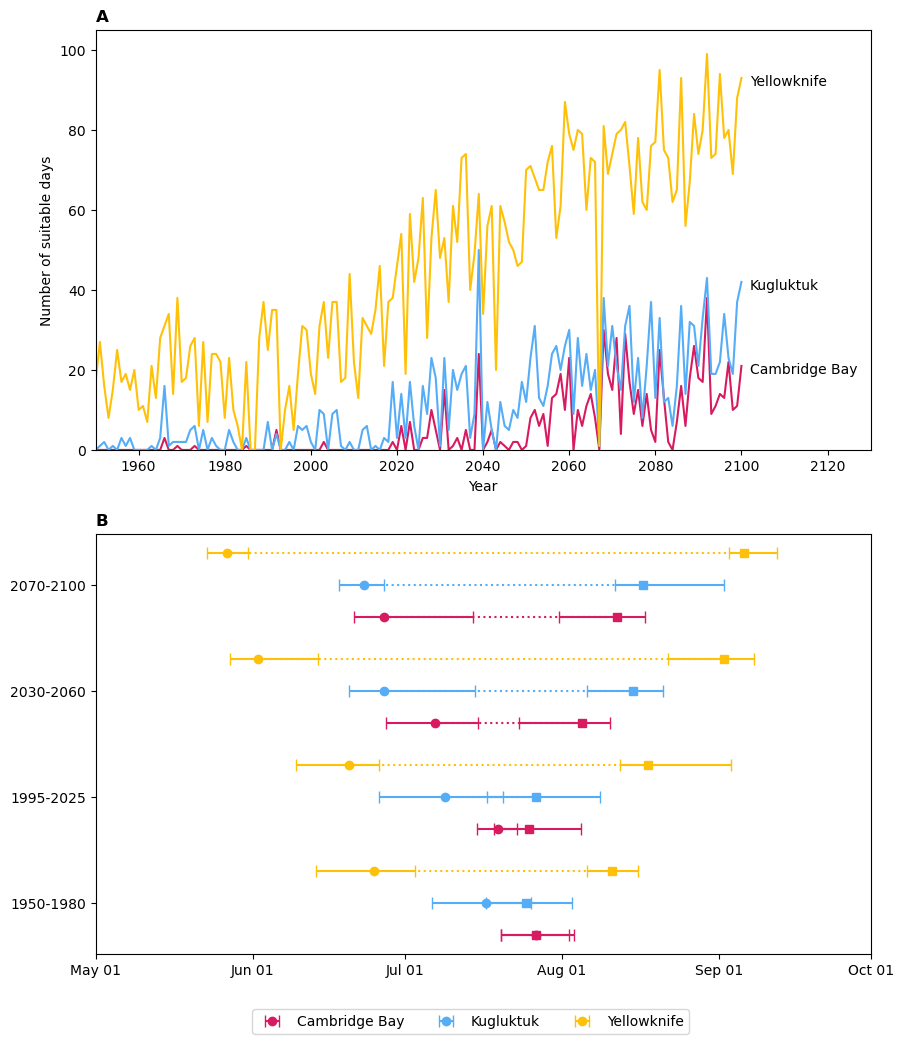

In [17]:
# Define time periods
periods = {
    "1950-1980": slice(1950, 1980),
    "1995-2025": slice(1995, 2025),
    "2030-2060": slice(2030, 2060),
    "2070-2100": slice(2070, 2100)
}

# Define locations
locations = {
    "Cambridge Bay": (lats[0], lons[0]),
    "Kugluktuk": (lats[1], lons[1]),
    "Yellowknife": (lats[2], lons[2])
}

# Define colours
colors = {
    "Cambridge Bay": "#D81B60",
    "Kugluktuk": "#56ADF7",
    "Yellowknife": "#FFC107"
}

fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (10,12))

#  Panel A: Number of suitable days over time at the three locations ----

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = ssp245_locations_low.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["year"]
    y = series["n_days"]
    
    axes[0].plot(x, y, color=colors[name])
    
    # Add label at the end of the line
    axes[0].text(
        x.values[-1] + 2,     # last year
        y[-1] - 1,            # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

axes[0].set_xlim(x.min(), x.max() + 30)
axes[0].set_ylim(y.min(), 105)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of suitable days")

axes[0].set_title("A", loc="left", fontweight="bold")


# Panel B: Start and end date of suitability ----
offsets = {
    "Cambridge Bay": -0.3,
    "Kugluktuk": 0.0,
    "Yellowknife": 0.3
}

for i, (period_name, yrs) in enumerate(periods.items()):

    for loc_name, (lat, lon) in locations.items():

        ds = ssp245_locations_low.sel(
            lat=lat,
            lon=lon,
            method="nearest"
        ).sel(year=yrs)

        
        # First day
        start = ds.first_day

        start_median = start.median("year").item()
        start_q25 = start.quantile(0.25, dim="year").item()
        start_q75 = start.quantile(0.75, dim="year").item()

        start_err = [
            [start_median - start_q25],
            [start_q75 - start_median]
        ]

        axes[1].errorbar(
            start_median,
            i + offsets[loc_name],
            xerr=start_err,
            fmt='o',
            color=colors[loc_name],
            capsize=4,
            label=loc_name if i == 0 else ""
        )

        # Last day
        end = ds.last_day

        end_median = end.median("year").item()
        end_q25 = end.quantile(0.25, dim="year").item()
        end_q75 = end.quantile(0.75, dim="year").item()

        end_err = [
            [end_median - end_q25],
            [end_q75 - end_median]
        ]

        axes[1].errorbar(
            end_median,
            i + offsets[loc_name],
            xerr=end_err,
            fmt='s',
            color=colors[loc_name],
            capsize=4
        )

        # Connect start and end dates
        axes[1].plot(
            [start_median, end_median],
            [i + offsets[loc_name], i + offsets[loc_name]],
            linestyle=":",
            color=colors[loc_name],
            linewidth=1.5,
            zorder=0
        )
        
# y-axis labels
period_labels = list(periods.keys())

axes[1].set_yticks(range(len(periods)))
axes[1].set_yticklabels(period_labels)

# Convert x axis from date of year to readable format
tick_days = [121, 152, 182, 213, 244, 274]

tick_labels = [
    (dt.datetime(2001, 1, 1) + dt.timedelta(days=d-1)).strftime("%b %d")
    for d in tick_days
]

axes[1].set_xticks(tick_days)
axes[1].set_xticklabels(tick_labels)

axes[1].set_title("B", loc="left", fontweight="bold")

# Shared legend
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.07)
)

plt.savefig("figures/S_locations.png", dpi=300, bbox_inches="tight")

plt.show()

151.0

In [58]:
# Load the dataset
data = xr.open_mfdataset("data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_*.nc")
    
# subset the dataset to the spatial domain
data = data.sel(lat = lats, lon= lons, method="nearest")

# subset summer temperature (June-August)
data_summer = data.sel(time = data.time.dt.month.isin(range(6,8)))
data_summer

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 9211, lat: 3, lon: 3)
Coordinates:
  * time     (time) object 74kB 1950-06-01 00:00:00 ... 2100-07-31 00:00:00
  * lat      (lat) float64 24B 69.12 67.79 62.46
  * lon      (lon) float64 24B -105.0 -115.1 -114.4
Data variables:
    tasmax   (time, lat, lon) float64 663kB dask.array<chunksize=(365, 3, 3), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 663kB dask.array<chunksize=(365, 3, 3), meta=np.ndarray>
    tas      (time, lat, lon) float64 663kB dask.array<chunksize=(365, 3, 3), meta=np.ndarray>
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [ ]:
#  Panel A: Number of suitable days over time at the three locations ----
fig, ax = plt.subplots(figsize=(10, 5))

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = data_summer.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["time"]
    y = series["tas"].mean('time')
    
    ax.plot(x, y, color=colors[name])
    
    # Add label at the end of the line
    ax.text(
        x.values[-1] + 2,     # last year
        y[-1] - 1,            # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

ax.set_xlim(x.min(), x.max() + 30)
ax.set_ylim(y.min(), 105)

ax.set_xlabel("Year")
ax.set_ylabel("Temperature (degC)")

Summary table showing the number of days suitable for transmission in different time periods

In [78]:
ssp245_locations_hist1_low = ssp245_locations_low.sel(year=slice(1950, 1980))
ssp245_locations_hist1_low = summary(ssp245_locations_hist1_low)

ssp245_locations_hist1_high = ssp245_locations_high.sel(year=slice(1950, 1980))
ssp245_locations_hist1_high = summary(ssp245_locations_hist1_high)


ssp245_locations_hist2_low = ssp245_locations_low.sel(year=slice(1995, 2025))
ssp245_locations_hist2_low = summary(ssp245_locations_hist2_low)

ssp245_locations_hist2_high = ssp245_locations_high.sel(year=slice(1995, 2025))
ssp245_locations_hist2_high = summary(ssp245_locations_hist2_high)


ssp245_locations_future1_low = ssp245_locations_low.sel(year=slice(2030, 2060))
ssp245_locations_future1_low = summary(ssp245_locations_future1_low)

ssp245_locations_future1_high = ssp245_locations_high.sel(year=slice(2030, 2060))
ssp245_locations_future1_high = summary(ssp245_locations_future1_high)


ssp245_locations_future2_low = ssp245_locations_low.sel(year=slice(2070, 2100))
ssp245_locations_future2_low = summary(ssp245_locations_future2_low)

ssp245_locations_future2_high = ssp245_locations_high.sel(year=slice(2070, 2100))
ssp245_locations_future2_high = summary(ssp245_locations_future2_high)

In [79]:
ssp245_locations_future2_high

<xarray.Dataset> Size: 480B
Dimensions:         (lon: 3, lat: 3)
Coordinates:
  * lon             (lon) float64 24B -115.1 -114.4 -105.0
  * lat             (lat) float64 24B 62.46 67.79 69.12
Data variables:
    n_days_mean     (lat, lon) float64 72B 40.45 39.9 16.55 ... 0.0 0.0 2.677
    n_days_std      (lat, lon) float64 72B 10.0 9.933 7.129 ... 0.0 0.0 2.988
    first_day_mean  (lat, lon) float64 72B 156.9 157.9 177.9 ... nan nan 184.7
    first_day_std   (lat, lon) float64 72B 12.33 12.33 13.68 ... nan nan 15.78
    last_day_mean   (lat, lon) float64 72B 238.6 239.0 228.5 ... nan nan 197.7
    last_day_std    (lat, lon) float64 72B 9.601 9.803 10.39 ... nan nan 17.15

In [80]:
## Cambridge Bay data
## 1950-1980
ssp245_hist1_low_CBAY = ssp245_locations_hist1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp245_hist1_high_CBAY = ssp245_locations_hist1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#1995-2025
ssp245_hist2_low_CBAY = ssp245_locations_hist2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp245_hist2_high_CBAY = ssp245_locations_hist2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2030-2060
ssp245_future1_low_CBAY = ssp245_locations_future1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp245_future1_high_CBAY = ssp245_locations_future1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2070-2100
ssp245_future2_low_CBAY = ssp245_locations_future2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp245_future2_high_CBAY = ssp245_locations_future2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

In [82]:
## Kugluktuk data
## 1950-1980
ssp245_hist1_low_KUG = ssp245_locations_hist1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp245_hist1_high_KUG = ssp245_locations_hist1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#1995-2025
ssp245_hist2_low_KUG = ssp245_locations_hist2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp245_hist2_high_KUG = ssp245_locations_hist2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2030-2060
ssp245_future1_low_KUG = ssp245_locations_future1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp245_future1_high_KUG = ssp245_locations_future1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2070-2100
ssp245_future2_low_KUG = ssp245_locations_future2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp245_future2_high_KUG = ssp245_locations_future2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

In [83]:
## Yellowknife data
## 1950-1980
ssp245_hist1_low_YKN = ssp245_locations_hist1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp245_hist1_high_YKN = ssp245_locations_hist1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#1995-2025
ssp245_hist2_low_YKN = ssp245_locations_hist2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp245_hist2_high_YKN = ssp245_locations_hist2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2030-2060
ssp245_future1_low_YKN = ssp245_locations_future1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp245_future1_high_YKN = ssp245_locations_future1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2070-2100
ssp245_future2_low_YKN = ssp245_locations_future2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp245_future2_high_YKN = ssp245_locations_future2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

In [90]:
ssp245_future2_high_YKN

<xarray.Dataset> Size: 64B
Dimensions:         ()
Coordinates:
    lon             float64 8B -114.4
    lat             float64 8B 62.46
Data variables:
    n_days_mean     float64 8B 39.9
    n_days_std      float64 8B 9.933
    first_day_mean  float64 8B 157.9
    first_day_std   float64 8B 12.33
    last_day_mean   float64 8B 239.0
    last_day_std    float64 8B 9.803

In [88]:
# Create a summary table showing the mean number of days suitable for transmission

rows = [
    # Cambridge Bay
    ["Cambridge Bay", "S(T)>0.001",
     f"{ssp245_hist1_low_CBAY.n_days_mean.item():.1f} ({ssp245_hist1_low_CBAY.n_days_std.item():.1f})",
     f"{ssp245_hist2_low_CBAY.n_days_mean.item():.1f} ({ssp245_hist2_low_CBAY.n_days_std.item():.1f})",
     f"{ssp245_future1_low_CBAY.n_days_mean.item():.1f} ({ssp245_future1_low_CBAY.n_days_std.item():.1f})",
     f"{ssp245_future2_low_CBAY.n_days_mean.item():.1f} ({ssp245_future2_low_CBAY.n_days_std.item():.1f})"],

    ["Cambridge Bay", "S(T)>0.5",
     f"{ssp245_hist1_high_CBAY.n_days_mean.item():.1f} ({ssp245_hist1_high_CBAY.n_days_std.item():.1f})",
     f"{ssp245_hist2_high_CBAY.n_days_mean.item():.1f} ({ssp245_hist2_high_CBAY.n_days_std.item():.1f})",
     f"{ssp245_future1_high_CBAY.n_days_mean.item():.1f} ({ssp245_future1_high_CBAY.n_days_std.item():.1f})",
     f"{ssp245_future2_high_CBAY.n_days_mean.item():.1f} ({ssp245_future2_high_CBAY.n_days_std.item():.1f})"],

    # Kugluktuk
    ["Kugluktuk", "S(T)>0.001",
     f"{ssp245_hist1_low_KUG.n_days_mean.item():.1f} ({ssp245_hist1_low_KUG.n_days_std.item():.1f})",
     f"{ssp245_hist2_low_KUG.n_days_mean.item():.1f} ({ssp245_hist2_low_KUG.n_days_std.item():.1f})",
     f"{ssp245_future1_low_KUG.n_days_mean.item():.1f} ({ssp245_future1_low_KUG.n_days_std.item():.1f})",
     f"{ssp245_future2_low_KUG.n_days_mean.item():.1f} ({ssp245_future2_low_KUG.n_days_std.item():.1f})"],

    ["Kugluktuk", "S(T)>0.5",
     f"{ssp245_hist1_high_KUG.n_days_mean.item():.1f} ({ssp245_hist1_high_KUG.n_days_std.item():.1f})",
     f"{ssp245_hist2_high_KUG.n_days_mean.item():.1f} ({ssp245_hist2_high_KUG.n_days_std.item():.1f})",
     f"{ssp245_future1_high_KUG.n_days_mean.item():.1f} ({ssp245_future1_high_KUG.n_days_std.item():.1f})",
     f"{ssp245_future2_high_KUG.n_days_mean.item():.1f} ({ssp245_future2_high_KUG.n_days_std.item():.1f})"],

    # Yellowknife
    ["Yellowknife", "S(T)>0.001",
     f"{ssp245_hist1_low_YKN.n_days_mean.item():.1f} ({ssp245_hist1_low_YKN.n_days_std.item():.1f})",
     f"{ssp245_hist2_low_YKN.n_days_mean.item():.1f} ({ssp245_hist2_low_YKN.n_days_std.item():.1f})",
     f"{ssp245_future1_low_YKN.n_days_mean.item():.1f} ({ssp245_future1_low_YKN.n_days_std.item():.1f})",
     f"{ssp245_future2_low_YKN.n_days_mean.item():.1f} ({ssp245_future2_low_YKN.n_days_std.item():.1f})"],

    ["Yellowknife", "S(T)>0.5",
     f"{ssp245_hist1_high_YKN.n_days_mean.item():.1f} ({ssp245_hist1_high_YKN.n_days_std.item():.1f})",
     f"{ssp245_hist2_high_YKN.n_days_mean.item():.1f} ({ssp245_hist2_high_YKN.n_days_std.item():.1f})",
     f"{ssp245_future1_high_YKN.n_days_mean.item():.1f} ({ssp245_future1_high_YKN.n_days_std.item():.1f})",
     f"{ssp245_future2_high_YKN.n_days_mean.item():.1f} ({ssp245_future2_high_YKN.n_days_std.item():.1f})"],
]

df_ssp245 = pd.DataFrame(
    rows,
    columns=[
        "Location", "Suitability threshold",
        "1950–1980", "1995–2025",
        "2030–2060", "2070–2100"
    ]
)

In [89]:
df_ssp245

,Location,Suitability threshold,1950–1980,1995–2025,2030–2060,2070–2100
0,Cambridge Bay,S(T)>0.001,0.2 (0.6),0.5 (1.6),5.7 (7.0),14.2 (8.7)
1,Cambridge Bay,S(T)>0.5,0.0 (0.0),0.1 (0.4),1.4 (2.4),2.7 (3.0)
2,Kugluktuk,S(T)>0.001,1.9 (3.0),4.5 (4.9),15.3 (10.8),24.3 (10.2)
3,Kugluktuk,S(T)>0.5,0.4 (1.3),0.9 (2.0),4.9 (4.9),8.4 (5.5)
4,Yellowknife,S(T)>0.001,19.1 (8.3),30.7 (12.8),58.1 (14.2),76.5 (11.0)
5,Yellowknife,S(T)>0.5,4.4 (4.8),7.6 (6.6),25.2 (12.3),39.9 (9.9)


In [31]:
# Create a summary table showing the mean number of days suitable for transmission

rows = [
    # Cambridge Bay
    ["Cambridge Bay", "S(T)>0.001",
     f"{ssp245_hist1_low_CBAY['mean'].mean('time').item():.1f} ({ssp245_hist1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_low_CBAY['mean'].mean('time').item():.1f} ({ssp245_hist2_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_future1_low_CBAY['mean'].mean('time').item():.1f} ({ssp245_future1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_future2_low_CBAY['mean'].mean('time').item():.1f} ({ssp245_future2_low_CBAY['mean'].std('time').item():.1f})"],

    ["Cambridge Bay", "S(T)>0.5",
     f"{ssp245_hist1_high_CBAY['mean'].mean('time').item():.1f} ({ssp245_hist1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_high_CBAY['mean'].mean('time').item():.1f} ({ssp245_hist2_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_future1_high_CBAY['mean'].mean('time').item():.1f} ({ssp245_future1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp245_future2_high_CBAY['mean'].mean('time').item():.1f} ({ssp245_future2_high_CBAY['mean'].std('time').item():.1f})"],

    # Kugluktuk
    ["Kugluktuk", "S(T)>0.001",
     f"{ssp245_hist1_low_KUG['mean'].mean('time').item():.1f} ({ssp245_hist1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_low_KUG['mean'].mean('time').item():.1f} ({ssp245_hist2_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_future1_low_KUG['mean'].mean('time').item():.1f} ({ssp245_future1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_future2_low_KUG['mean'].mean('time').item():.1f} ({ssp245_future2_low_KUG['mean'].std('time').item():.1f})"],

    ["Kugluktuk", "S(T)>0.5",
     f"{ssp245_hist1_high_KUG['mean'].mean('time').item():.1f} ({ssp245_hist1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_high_KUG['mean'].mean('time').item():.1f} ({ssp245_hist2_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_future1_high_KUG['mean'].mean('time').item():.1f} ({ssp245_future1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp245_future2_high_KUG['mean'].mean('time').item():.1f} ({ssp245_future2_high_KUG['mean'].std('time').item():.1f})"],

    # Yellowknife
    ["Yellowknife", "S(T)>0.001",
     f"{ssp245_hist1_low_YKN['mean'].mean('time').item():.1f} ({ssp245_hist1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_low_YKN['mean'].mean('time').item():.1f} ({ssp245_hist2_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_future1_low_YKN['mean'].mean('time').item():.1f} ({ssp245_future1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_future2_low_YKN['mean'].mean('time').item():.1f} ({ssp245_future2_low_YKN['mean'].std('time').item():.1f})"],

    ["Yellowknife", "S(T)>0.5",
     f"{ssp245_hist1_high_YKN['mean'].mean('time').item():.1f} ({ssp245_hist1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_hist2_high_YKN['mean'].mean('time').item():.1f} ({ssp245_hist2_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_future1_high_YKN['mean'].mean('time').item():.1f} ({ssp245_future1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp245_future2_high_YKN['mean'].mean('time').item():.1f} ({ssp245_future2_high_YKN['mean'].std('time').item():.1f})"],
]

df_ssp245 = pd.DataFrame(
    rows,
    columns=[
        "Location", "Suitability threshold",
        "1950–1980", "1995–2025",
        "2030–2060", "2070–2100"
    ]
)

In [32]:
df_ssp245

,Location,Suitability threshold,1950–1980,1995–2025,2030–2060,2070–2100
0,Cambridge Bay,S(T)>0.001,0.2 (0.6),0.5 (1.6),5.7 (7.0),14.2 (8.7)
1,Cambridge Bay,S(T)>0.5,0.0 (0.0),0.1 (0.4),1.4 (2.4),2.7 (3.0)
2,Kugluktuk,S(T)>0.001,1.9 (3.0),4.5 (4.9),15.3 (10.8),24.3 (10.2)
3,Kugluktuk,S(T)>0.5,0.4 (1.3),0.9 (2.0),4.9 (4.9),8.4 (5.5)
4,Yellowknife,S(T)>0.001,19.1 (8.3),30.7 (12.8),58.1 (14.2),76.5 (11.0)
5,Yellowknife,S(T)>0.5,4.4 (4.8),7.6 (6.6),25.2 (12.3),39.9 (9.9)


In [33]:
df_ssp245.to_csv("data-processed/S.ssp245.locations.meandays.csv", index=False)

#### Compare to Thomas et al. 2025

In [60]:
# Tuk Peninsula
loc1_lat = 68.6941
loc1_lon = -133.2518

# Cape Bathurst
loc2_lat = 68.2897
loc2_lon = -128.00323

# Bluenose West
loc3_lat = 67.3412
loc3_lon = -123.7118

# North Slave
loc4_lat = 64.7110
loc4_lon = -111.4066

# North Dehcho
loc5_lat = 61.2824
loc5_lon = -120.4256

# Labrador
loc6_lat = 52.8370
loc6_lon = -60.4654

# D&U
loc7_lat = 67.7225
loc7_lon = -110.7751

In [61]:
# Tuk Peninsula
ssp245_hist2_low_loc1 = ssp245_hist2_low.sel(lat = loc1_lat, lon= loc1_lon, method="nearest")

# Cape Bathurst
ssp245_hist2_low_loc2 = ssp245_hist2_low.sel(lat = loc2_lat, lon= loc2_lon, method="nearest")

# Bluenose West
ssp245_hist2_low_loc3 = ssp245_hist2_low.sel(lat = loc3_lat, lon= loc3_lon, method="nearest")

# North Slave
ssp245_hist2_low_loc4 = ssp245_hist2_low.sel(lat = loc4_lat, lon= loc4_lon, method="nearest")

# North Dehcho
ssp245_hist2_low_loc5 = ssp245_hist2_low.sel(lat = loc5_lat, lon= loc5_lon, method="nearest")

# Labrador
ssp245_hist2_low_loc6 = ssp245_hist2_low.sel(lat = loc6_lat, lon= loc6_lon, method="nearest")

# D&U
ssp245_hist2_low_loc7 = ssp245_hist2_low.sel(lat = loc7_lat, lon= loc7_lon, method="nearest")

In [62]:
# Create a summary table showing the mean number of days suitable for transmission

rows = [
    # Tuk Peninsula
    ["Tuk Peninsula", f"{ssp245_hist2_low_loc1['mean'].mean('time').item():.1f}"],

    # Cape Bathurst
    ["Cape Bathurst", f"{ssp245_hist2_low_loc2['mean'].mean('time').item():.1f}"],

    # North Slave
    ["Bluenose West", f"{ssp245_hist2_low_loc3['mean'].mean('time').item():.1f}"],

    # North Slave
    ["North Slave", f"{ssp245_hist2_low_loc4['mean'].mean('time').item():.1f}"],

    # North Dehcho
    ["North Dehcho", f"{ssp245_hist2_low_loc5['mean'].mean('time').item():.1f}"],

    # Labrador
    ["Labrador", f"{ssp245_hist2_low_loc6['mean'].mean('time').item():.1f}"],

    # D&U
    ["D&U", f"{ssp245_hist2_low_loc7['mean'].mean('time').item():.1f}"],
]

Thomas2025 = pd.DataFrame(
    rows,
    columns=[
        "Location", "Number of suitable days"
    ]
)

Thomas2025

,Location,Number of suitable days
0,Tuk Peninsula,12.6
1,Cape Bathurst,7.8
2,Bluenose West,5.5
3,North Slave,6.2
4,North Dehcho,38.0
5,Labrador,15.3
6,D&U,1.2


D:\anaconda\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


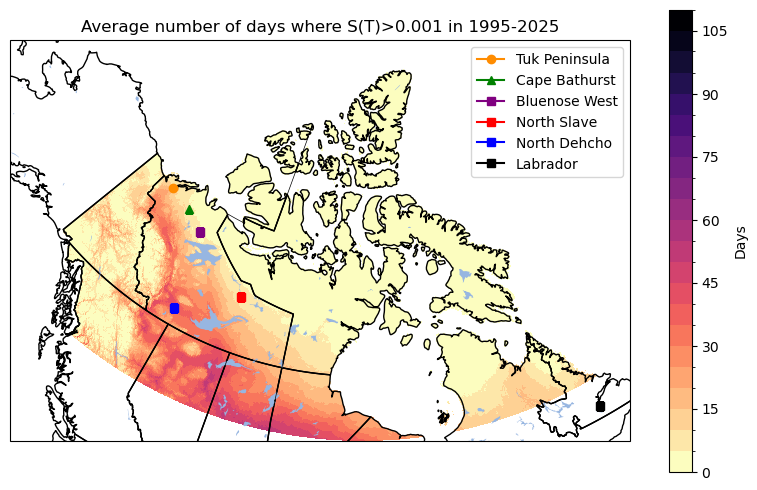

In [59]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_hist2_low["mean"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

ax.plot(loc1_lon, loc1_lat, marker = 'o', color = 'darkorange', transform=ccrs.PlateCarree(), label = 'Tuk Peninsula')
ax.plot(loc2_lon, loc2_lat, marker = '^', color = 'green', transform=ccrs.PlateCarree(), label = 'Cape Bathurst')
ax.plot(loc3_lon, loc3_lat, marker = 's', color = 'purple', transform=ccrs.PlateCarree(), label = 'Bluenose West')
ax.plot(loc4_lon, loc4_lat, marker = 's', color = 'red', transform=ccrs.PlateCarree(), label = 'North Slave')
ax.plot(loc5_lon, loc5_lat, marker = 's', color = 'blue', transform=ccrs.PlateCarree(), label = 'North Dehcho')
ax.plot(loc6_lon, loc6_lat, marker = 's', color = 'black', transform=ccrs.PlateCarree(), label = 'Labrador')
ax.legend()

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 1995-2025")

plt.show()

#### Mean summer temperature

In [145]:
# Load data
data = xr.open_mfdataset("data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_*.nc")

In [146]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

In [149]:
# Extract summer temperature (May - Sept)
data_summer = data.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds),
                       time = data.time.dt.month.isin(range(6,8)))
data_summer

<xarray.Dataset> Size: 74GB
Dimensions:  (time: 9211, lat: 342, lon: 984)
Coordinates:
  * time     (time) object 74kB 1950-06-01 00:00:00 ... 2100-07-31 00:00:00
  * lat      (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
  * lon      (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
Data variables:
    tasmax   (time, lat, lon) float64 25GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 25GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
    tas      (time, lat, lon) float64 25GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [150]:
# Subset data based on their time period
data_hist1 = data_summer.sel(time = data_summer.time.dt.year.isin(range(1950, 1981)))
data_hist2 = data_summer.sel(time = data_summer.time.dt.year.isin(range(1995, 2026)))
data_future1 = data_summer.sel(time = data_summer.time.dt.year.isin(range(2030, 2061)))
data_future2 = data_summer.sel(time = data_summer.time.dt.year.isin(range(2070, 2101)))
data_future2

<xarray.Dataset> Size: 15GB
Dimensions:  (time: 1891, lat: 342, lon: 984)
Coordinates:
  * time     (time) object 15kB 2070-06-01 00:00:00 ... 2100-07-31 00:00:00
  * lat      (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
  * lon      (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
Data variables:
    tasmax   (time, lat, lon) float64 5GB dask.array<chunksize=(354, 342, 984), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 5GB dask.array<chunksize=(354, 342, 984), meta=np.ndarray>
    tas      (time, lat, lon) float64 5GB dask.array<chunksize=(354, 342, 984), meta=np.ndarray>
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [ ]:
levels = np.arange(-5, 22.5, 0.5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
data_future2["tas"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'RdBu_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average summer temperature in 2070-2100")

plt.savefig("figures/summertemp.2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

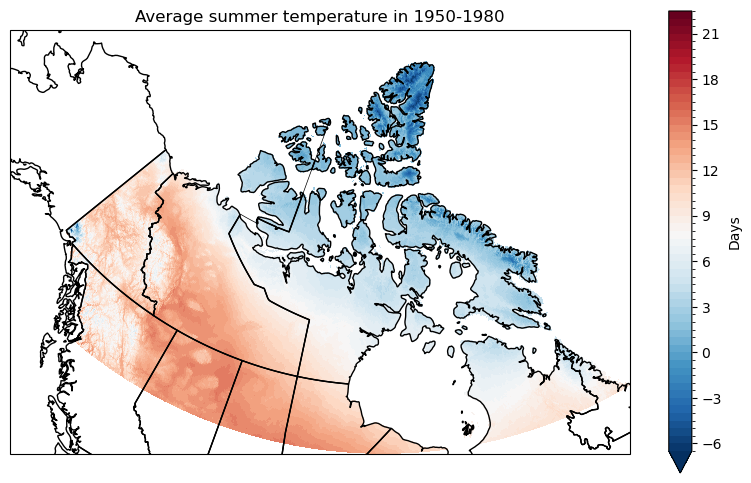

In [16]:
levels = np.arange(-7, 23, 0.5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
data_hist1["tas"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'RdBu_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average summer temperature in 1950-1980")

#plt.savefig("figures/S_0.05_2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

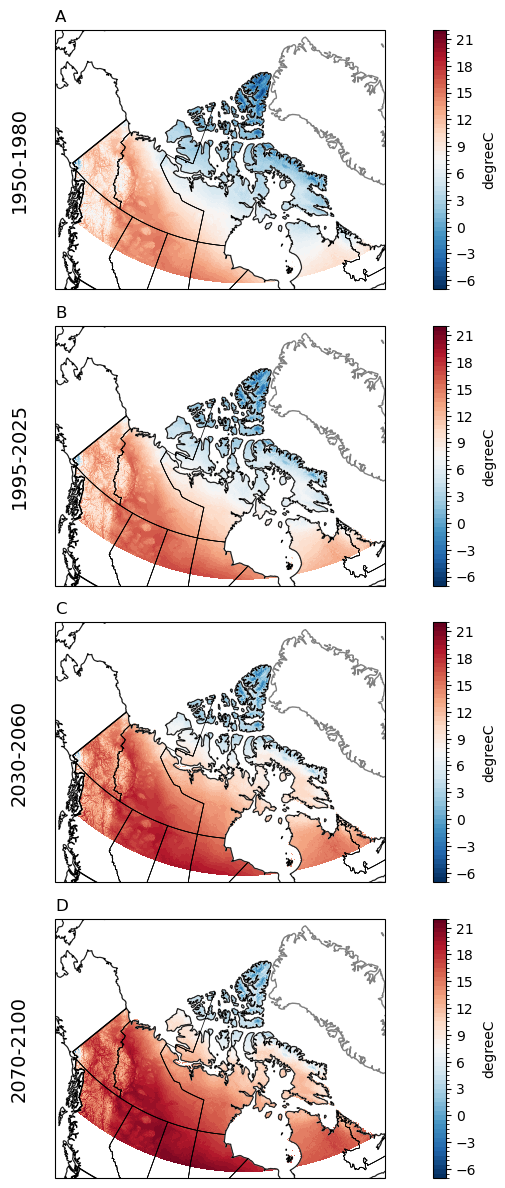

In [8]:
# plot all historical and future simulations
levels = np.arange(-7, 22.5, 0.5)
cmap = 'RdBu_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 1, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980
data_hist1["tas"].mean('time').plot.pcolormesh(ax = axes[0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'degreeC', 'orientation': 'vertical'}
                                                     )
axes[0].set_title("A", loc='left')


# Historical 2: 1995-2025
data_hist2["tas"].mean('time').plot.pcolormesh(ax = axes[1], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'degreeC', 'orientation': 'vertical'}
                                                     )
axes[1].set_title("B", loc='left')



# Future 1: 2030-2060
data_future1["tas"].mean('time').plot.pcolormesh(ax = axes[2],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'degreeC', 'orientation': 'vertical'}
                                                       )
axes[2].set_title("C", loc='left')



# Future 2: 2070-2100
data_future2["tas"].mean('time').plot.pcolormesh(ax = axes[3],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'degreeC', 'orientation': 'vertical'}
                                                       )
axes[3].set_title("D", loc='left')



for ax in axes.flat: # flat makes axes 1D instead of 2D
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())


# Column and row labels
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Row headers
for row, label in enumerate(rows):
    axes[row].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/summer_temp_ssp245.png", dpi=300, bbox_inches="tight")

plt.show()

#### Maximum summer temperature

In [2]:
# Load data
data = xr.open_mfdataset("data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_*.nc")

In [3]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

In [4]:
# Extract summer temperature (May - Sept)
data_summer = data.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds),
                       time = data.time.dt.month.isin(range(6,9)))
data_summer

<xarray.Dataset> Size: 92GB
Dimensions:  (time: 11408, lat: 342, lon: 984)
Coordinates:
  * time     (time) object 91kB 1950-06-01 00:00:00 ... 2100-08-31 00:00:00
  * lat      (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
  * lon      (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
Data variables:
    tasmax   (time, lat, lon) float64 31GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 31GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
    tas      (time, lat, lon) float64 31GB dask.array<chunksize=(365, 342, 984), meta=np.ndarray>
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [5]:
# Subset data based on their time period
data_hist1 = data_summer.sel(time = data_summer.time.dt.year.isin(range(1950, 1981)))
data_hist2 = data_summer.sel(time = data_summer.time.dt.year.isin(range(1995, 2026)))
data_future1 = data_summer.sel(time = data_summer.time.dt.year.isin(range(2030, 2061)))
data_future2 = data_summer.sel(time = data_summer.time.dt.year.isin(range(2070, 2101)))
data_future2

<xarray.Dataset> Size: 23GB
Dimensions:  (time: 2852, lat: 342, lon: 984)
Coordinates:
  * time     (time) object 23kB 2070-06-01 00:00:00 ... 2100-08-31 00:00:00
  * lat      (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
  * lon      (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
Data variables:
    tasmax   (time, lat, lon) float64 8GB dask.array<chunksize=(356, 342, 984), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 8GB dask.array<chunksize=(356, 342, 984), meta=np.ndarray>
    tas      (time, lat, lon) float64 8GB dask.array<chunksize=(356, 342, 984), meta=np.ndarray>
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [10]:
data_future2["tas"].max(('time', 'lat', 'lon')).compute().item()

35.834282568

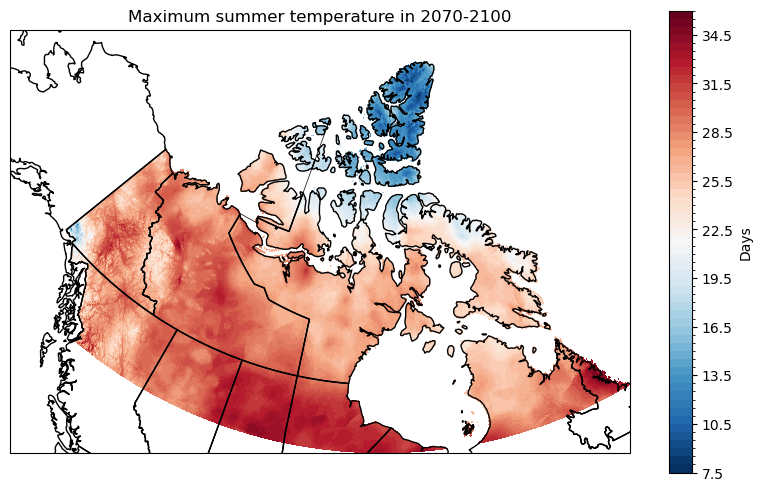

In [16]:
levels = np.arange(7.5, 36.5, 0.5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
data_future2["tas"].max('time').plot.pcolormesh(ax = ax, 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = 'RdBu_r',
                                                cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                               )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Maximum summer temperature in 2070-2100")

plt.savefig("figures/max.summertemp.2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

## 2b. SSP1-2.6

### 2b.i Saving the climate data

In [3]:
ssp126_url = datasets_canesm_sds[1] #SSP1-2.6; ensemble member: r1i1p2f1
print(ssp126_url)
ssp126_all = xr.open_dataset(ssp126_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r1i1p2f1_gn_1950-2100.ncml


In [5]:
ssp126 = ssp126_all

In [6]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1950...
Finished processing year 1950. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1950.nc
Processing year 1951...
Finished processing year 1951. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1951.nc
Processing year 1952...
Finished processing year 1952. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1952.nc
Processing year 1953...
Finished processing year 1953. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1953.nc
Processing year 1954...
Finished processing year 1954. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1954.nc
Processing year 1955...
Finished processing year 1955. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1955.nc
Processing year 1956...
Finished processing year 1956. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1956.nc
Proces

In [10]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1995...
Finished processing year 1995. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1995.nc
Processing year 1996...
Finished processing year 1996. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1996.nc
Processing year 1997...
Finished processing year 1997. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1997.nc
Processing year 1998...
Finished processing year 1998. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1998.nc
Processing year 1999...
Finished processing year 1999. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_1999.nc
Processing year 2000...
Finished processing year 2000. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2000.nc
Processing year 2001...
Finished processing year 2001. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2001.nc
Proces

In [11]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 2030...
Finished processing year 2030. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2030.nc
Processing year 2031...
Finished processing year 2031. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2031.nc
Processing year 2032...
Finished processing year 2032. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2032.nc
Processing year 2033...
Finished processing year 2033. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2033.nc
Processing year 2034...
Finished processing year 2034. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2034.nc
Processing year 2035...
Finished processing year 2035. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2035.nc
Processing year 2036...
Finished processing year 2036. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2036.nc
Proces

In [15]:
start_year = 2070
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp126.sel(time = ssp126.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 2070...
Finished processing year 2070. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2070.nc
Processing year 2071...
Finished processing year 2071. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2071.nc
Processing year 2072...
Finished processing year 2072. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2072.nc
Processing year 2073...
Finished processing year 2073. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2073.nc
Processing year 2074...
Finished processing year 2074. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2074.nc
Processing year 2075...
Finished processing year 2075. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2075.nc
Processing year 2076...
Finished processing year 2076. Now saving file...
Saved data-raw/climate-data/tas_day_CanESM5_ssp126_r1i1p2f1_2076.nc
Proces

### 2b.ii. Calculate suitability

In [7]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

#### Historical 1: 1950-1980

##### S(T) > 0.001

In [8]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_hist1_low = xr.concat(suit_list, dim="time")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


##### S(T) > 0.5

In [22]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_hist1_high = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


#### Historical 2: 1995-2025

##### S(T) > 0.001

In [10]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_hist2_low = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


##### S(T) > 0.5

In [11]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_hist2_high = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


#### Future 1: 2030-2060

##### S(T) > 0.001

In [12]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_future1_low = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


##### S(T) > 0.5

In [13]:
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_future1_high = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


#### Future 2: 2700-2100

##### S(T) > 0.001

In [14]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_future2_low = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


##### S(T) > 0.5

In [15]:
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp126/tas_day_CanESM5_ssp126_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp126_future2_high = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


### 2b.iii. Mapping

#### Future 2: 2700-2100

##### S(T) > 0.001

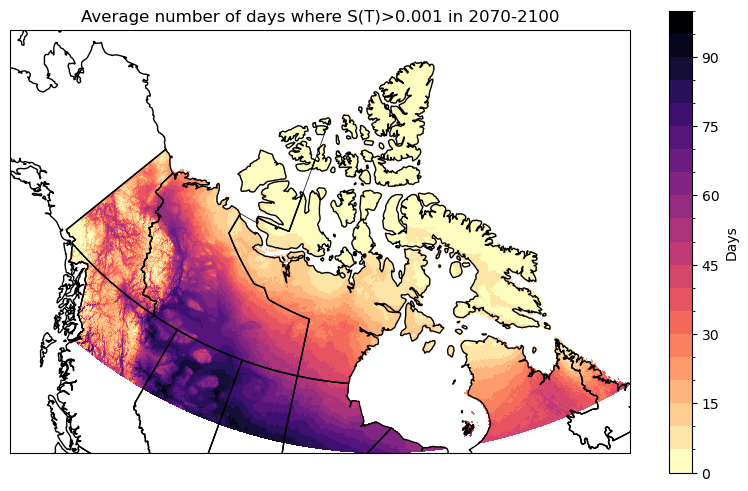

In [20]:
levels = np.arange(0, 105, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp126_future2_low["mean"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 2070-2100")

plt.savefig("figures/S_ssp126_0.001_2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

#### All time periods 

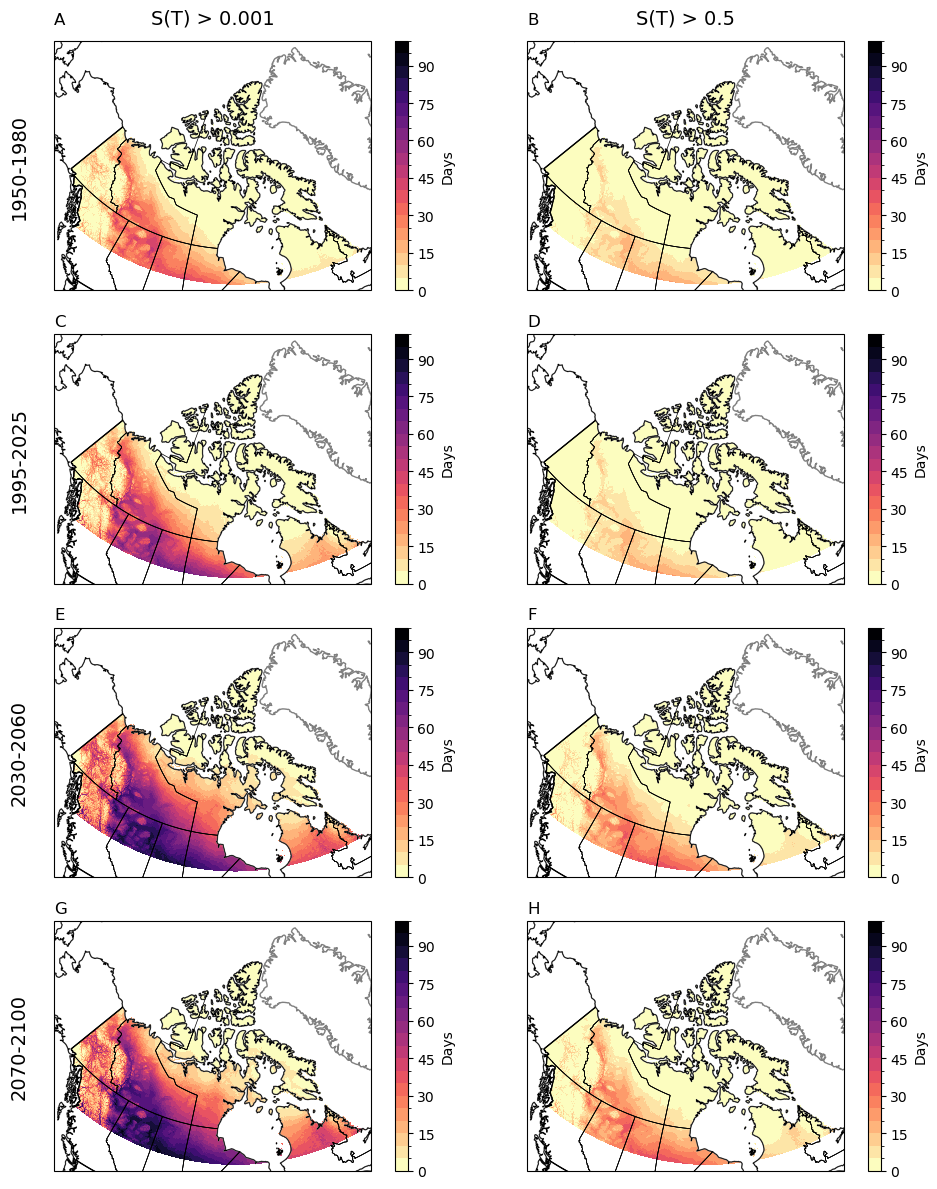

In [23]:
# plot all historical and future simulations
levels = np.arange(0, 105, 5)
cmap = 'magma_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 2, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980, S(T) > 0.001
ssp126_hist1_low["mean"].mean('time').plot.pcolormesh(ax = axes[0,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[0,0].set_title("A", loc='left')

# Historical 1: 1950-1980, S(T) > 0.5
ssp126_hist1_high["mean"].mean('time').plot.pcolormesh(ax = axes[0,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[0,1].set_title("B", loc='left')

# Historical 2: 1995-2025, S(T) > 0.001
ssp126_hist2_low["mean"].mean('time').plot.pcolormesh(ax = axes[1,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[1,0].set_title("C", loc='left')


# Historical 2: 1995-2025, S(T) > 0.5
ssp126_hist2_high["mean"].mean('time').plot.pcolormesh(ax = axes[1,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[1,1].set_title("D", loc='left')

# Future 1: 2030-2060, S(T) > 0.001
ssp126_future1_low["mean"].mean('time').plot.pcolormesh(ax = axes[2,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[2,0].set_title("E", loc='left')


# Future 1: 2030-2060, S(T) > 0.5
ssp126_future1_high["mean"].mean('time').plot.pcolormesh(ax = axes[2,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[2,1].set_title("F", loc='left')

# Future 2: 2070-2100, S(T) > 0.001
ssp126_future2_low["mean"].mean('time').plot.pcolormesh(ax = axes[3,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[3,0].set_title("G", loc='left')


# Future 2: 2070-2100, S(T) > 0.5
ssp126_future2_high["mean"].mean('time').plot.pcolormesh(ax = axes[3,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[3,1].set_title("H", loc='left')

for ax in axes.flat: # flat makes axes 1D instead of 2D
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())


# Column and row labels
cols = ["S(T) > 0.001", "S(T) > 0.5"]
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Column headers
for col, label in enumerate(cols):
    axes[0, col].set_title(label, fontsize=14, pad=12) # Add column 

# Row headers
for row, label in enumerate(rows):
    axes[row, 0].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row, 0].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/S_ssp126_lowerCI.png", dpi=300, bbox_inches="tight")

plt.show()

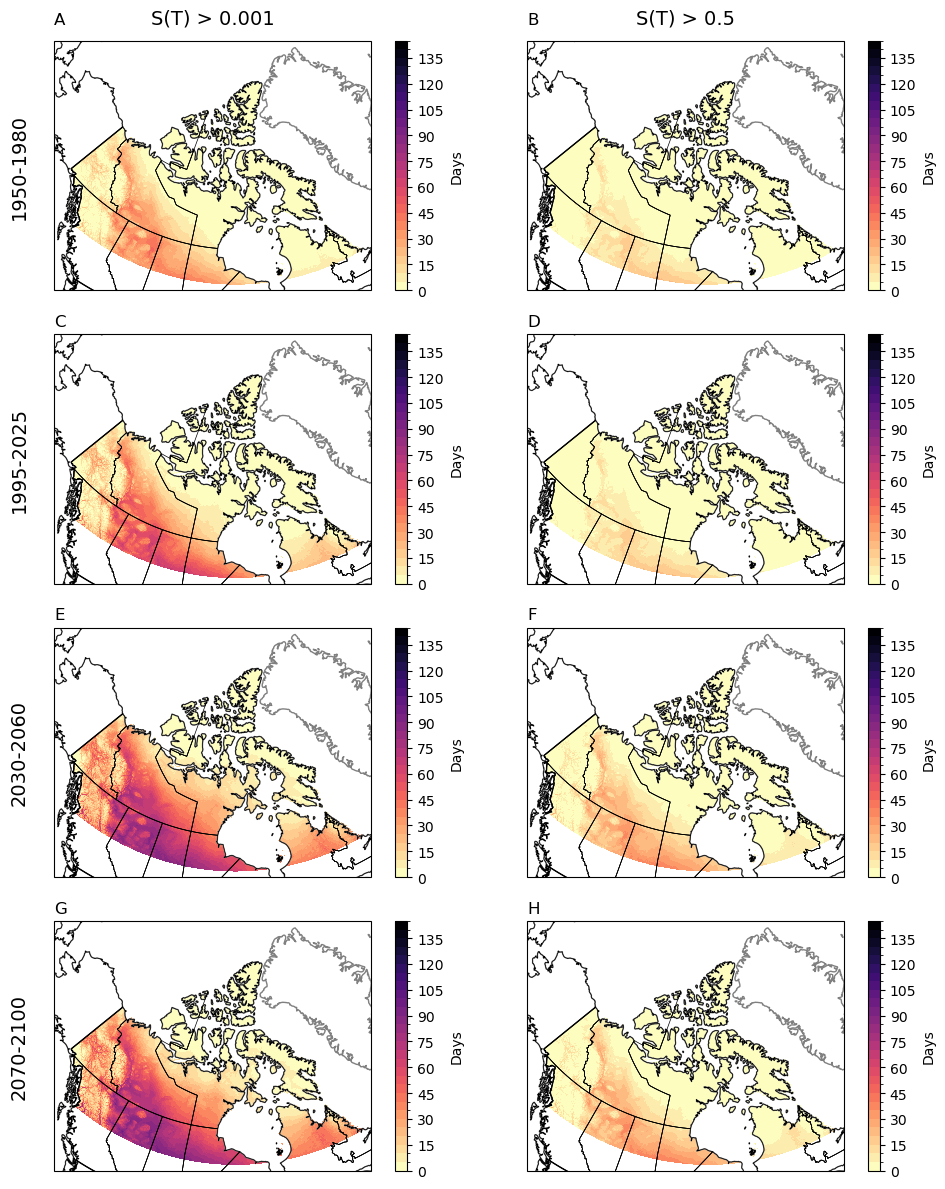

In [41]:
# plot all historical and future simulations
levels = np.arange(0, 150, 5)
cmap = 'magma_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 2, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980, S(T) > 0.001
ssp126_hist1_low["mean"].mean('time').plot.pcolormesh(ax = axes[0,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[0,0].set_title("A", loc='left')

# Historical 1: 1950-1980, S(T) > 0.5
ssp126_hist1_high["mean"].mean('time').plot.pcolormesh(ax = axes[0,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[0,1].set_title("B", loc='left')

# Historical 2: 1995-2025, S(T) > 0.001
ssp126_hist2_low["mean"].mean('time').plot.pcolormesh(ax = axes[1,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[1,0].set_title("C", loc='left')


# Historical 2: 1995-2025, S(T) > 0.5
ssp126_hist2_high["mean"].mean('time').plot.pcolormesh(ax = axes[1,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[1,1].set_title("D", loc='left')

# Future 1: 2030-2060, S(T) > 0.001
ssp126_future1_low["mean"].mean('time').plot.pcolormesh(ax = axes[2,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[2,0].set_title("E", loc='left')


# Future 1: 2030-2060, S(T) > 0.5
ssp126_future1_high["mean"].mean('time').plot.pcolormesh(ax = axes[2,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[2,1].set_title("F", loc='left')

# Future 2: 2070-2100, S(T) > 0.001
ssp126_future2_low["mean"].mean('time').plot.pcolormesh(ax = axes[3,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[3,0].set_title("G", loc='left')


# Future 2: 2070-2100, S(T) > 0.5
ssp126_future2_high["mean"].mean('time').plot.pcolormesh(ax = axes[3,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[3,1].set_title("H", loc='left')

for ax in axes.flat: # flat makes axes 1D instead of 2D
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())


# Column and row labels
cols = ["S(T) > 0.001", "S(T) > 0.5"]
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Column headers
for col, label in enumerate(cols):
    axes[0, col].set_title(label, fontsize=14, pad=12) # Add column 

# Row headers
for row, label in enumerate(rows):
    axes[row, 0].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row, 0].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/S_ssp126_lowerCI2.png", dpi=300, bbox_inches="tight")

plt.show()

#### Cambridge Bay, Kugluktuk, and Yellowknife

In [42]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

In [43]:
## Cambridge Bay data
## 1950-1980
ssp126_hist1_low_CBAY = ssp126_hist1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp126_hist1_high_CBAY = ssp126_hist1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#1995-2025
ssp126_hist2_low_CBAY = ssp126_hist2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp126_hist2_high_CBAY = ssp126_hist2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2030-2060
ssp126_future1_low_CBAY = ssp126_future1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp126_future1_high_CBAY = ssp126_future1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2070-2100
ssp126_future2_low_CBAY = ssp126_future2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp126_future2_high_CBAY = ssp126_future2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

In [44]:
## Kugluktuk data
## 1950-1980
ssp126_hist1_low_KUG = ssp126_hist1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp126_hist1_high_KUG = ssp126_hist1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#1995-2025
ssp126_hist2_low_KUG = ssp126_hist2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp126_hist2_high_KUG = ssp126_hist2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2030-2060
ssp126_future1_low_KUG = ssp126_future1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp126_future1_high_KUG = ssp126_future1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2070-2100
ssp126_future2_low_KUG = ssp126_future2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp126_future2_high_KUG = ssp126_future2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

In [45]:
## Yellowknife data
## 1950-1980
ssp126_hist1_low_YKN = ssp126_hist1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp126_hist1_high_YKN = ssp126_hist1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#1995-2025
ssp126_hist2_low_YKN = ssp126_hist2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp126_hist2_high_YKN = ssp126_hist2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2030-2060
ssp126_future1_low_YKN = ssp126_future1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp126_future1_high_YKN = ssp126_future1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2070-2100
ssp126_future2_low_YKN = ssp126_future2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp126_future2_high_YKN = ssp126_future2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

In [56]:
# Create a summary table showing the mean number of days suitable for transmission

rows = [
    # Cambridge Bay
    ["Cambridge Bay", "S(T)>0.001",
     f"{ssp126_hist1_low_CBAY['mean'].mean('time').item():.1f} ({ssp126_hist1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_low_CBAY['mean'].mean('time').item():.1f} ({ssp126_hist2_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_future1_low_CBAY['mean'].mean('time').item():.1f} ({ssp126_future1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_future2_low_CBAY['mean'].mean('time').item():.1f} ({ssp126_future2_low_CBAY['mean'].std('time').item():.1f})"],

    ["Cambridge Bay", "S(T)>0.5",
     f"{ssp126_hist1_high_CBAY['mean'].mean('time').item():.1f} ({ssp126_hist1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_high_CBAY['mean'].mean('time').item():.1f} ({ssp126_hist2_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_future1_high_CBAY['mean'].mean('time').item():.1f} ({ssp126_future1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp126_future2_high_CBAY['mean'].mean('time').item():.1f} ({ssp126_future2_high_CBAY['mean'].std('time').item():.1f})"],

    # Kugluktuk
    ["Kugluktuk", "S(T)>0.001",
     f"{ssp126_hist1_low_KUG['mean'].mean('time').item():.1f} ({ssp126_hist1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_low_KUG['mean'].mean('time').item():.1f} ({ssp126_hist2_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_future1_low_KUG['mean'].mean('time').item():.1f} ({ssp126_future1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_future2_low_KUG['mean'].mean('time').item():.1f} ({ssp126_future2_low_KUG['mean'].std('time').item():.1f})"],

    ["Kugluktuk", "S(T)>0.5",
     f"{ssp126_hist1_high_KUG['mean'].mean('time').item():.1f} ({ssp126_hist1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_high_KUG['mean'].mean('time').item():.1f} ({ssp126_hist2_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_future1_high_KUG['mean'].mean('time').item():.1f} ({ssp126_future1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp126_future2_high_KUG['mean'].mean('time').item():.1f} ({ssp126_future2_high_KUG['mean'].std('time').item():.1f})"],

    # Yellowknife
    ["Yellowknife", "S(T)>0.001",
     f"{ssp126_hist1_low_YKN['mean'].mean('time').item():.1f} ({ssp126_hist1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_low_YKN['mean'].mean('time').item():.1f} ({ssp126_hist2_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_future1_low_YKN['mean'].mean('time').item():.1f} ({ssp126_future1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_future2_low_YKN['mean'].mean('time').item():.1f} ({ssp126_future2_low_YKN['mean'].std('time').item():.1f})"],

    ["Yellowknife", "S(T)>0.5",
     f"{ssp126_hist1_high_YKN['mean'].mean('time').item():.1f} ({ssp126_hist1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_hist2_high_YKN['mean'].mean('time').item():.1f} ({ssp126_hist2_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_future1_high_YKN['mean'].mean('time').item():.1f} ({ssp126_future1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp126_future2_high_YKN['mean'].mean('time').item():.1f} ({ssp126_future2_high_YKN['mean'].std('time').item():.1f})"],
]

df_ssp126 = pd.DataFrame(
    rows,
    columns=[
        "Location", "Suitability threshold",
        "1950–1980", "1995–2025",
        "2030–2060", "2070–2100"
    ]
)

In [57]:
df_ssp126

,Location,Suitability threshold,1950–1980,1995–2025,2030–2060,2070–2100
0,Cambridge Bay,S(T)>0.001,0.4 (1.1),1.9 (3.5),9.4 (8.0),7.2 (5.1)
1,Cambridge Bay,S(T)>0.5,0.1 (0.5),0.1 (0.5),0.6 (1.1),0.4 (0.7)
2,Kugluktuk,S(T)>0.001,3.8 (4.0),7.6 (6.7),18.5 (8.8),18.1 (8.8)
3,Kugluktuk,S(T)>0.5,0.9 (1.7),0.9 (1.7),4.0 (3.2),4.2 (4.0)
4,Yellowknife,S(T)>0.001,28.4 (9.9),41.4 (13.1),67.6 (10.8),71.5 (10.5)
5,Yellowknife,S(T)>0.5,8.2 (6.9),8.2 (6.9),23.6 (10.1),24.3 (9.4)


In [58]:
df_ssp126.to_csv("data-processed/S.ssp126.locations.meandays.csv", index=False)

## 2c. SSP5-8.5

### 2c.i Saving the climate data

In [13]:
ssp585_url = datasets_canesm_sds[21] #SSP5-8.5; ensemble member: r1i1p2f1
print(ssp585_url)
ssp585_all = xr.open_dataset(ssp585_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r1i1p2f1_gn_1950-2100.ncml


In [17]:
ssp585 = ssp585_all

In [18]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1950...


KeyboardInterrupt: 

In [ ]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2700
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp585.sel(time = ssp585.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

### 2c.ii. Calculate suitability

In [24]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

#### Historical 1: 1950-1980

##### S(T) > 0.001

In [25]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist1_low = xr.concat(suit_list, dim="time")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


##### S(T) > 0.5

In [26]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist1_high = xr.concat(suit_list, dim="time")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


#### Historical 2: 1995-2025

##### S(T) > 0.001

In [27]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist2_low = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


##### S(T) > 0.5

In [28]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_hist2_high = xr.concat(suit_list, dim="time")

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


#### Future 1: 2030-2060

##### S(T) > 0.001

In [29]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future1_low = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


##### S(T) > 0.5

In [30]:
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future1_high = xr.concat(suit_list, dim="time")

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


#### Future 2: 2700-2100

##### S(T) > 0.001

In [32]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.001)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future2_low = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


##### S(T) > 0.5

In [33]:
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp585/tas_day_CanESM5_ssp585_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = get_suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp585_future2_high = xr.concat(suit_list, dim="time")

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


### 2c.iii. Mapping

#### Future 2: 2070-2100

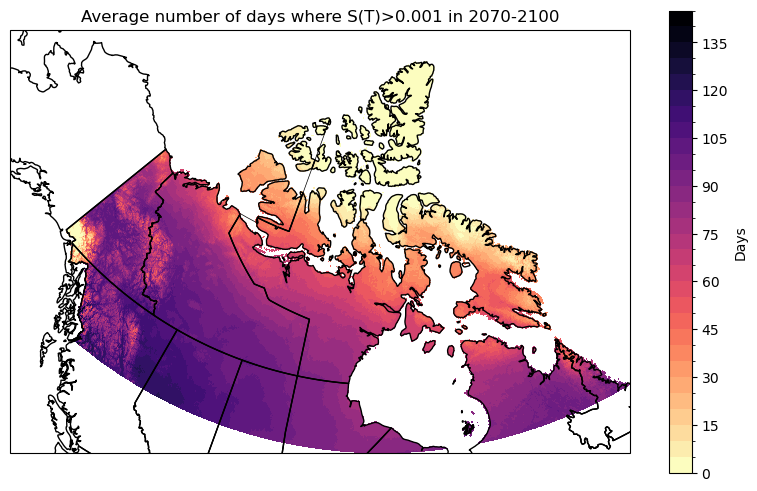

In [39]:
levels = np.arange(0, 150, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp585_future2_low["mean"].mean('time').plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0.001 in 2070-2100")

plt.savefig("figures/S_ssp585_0.001_2070-2100.png", dpi=300, bbox_inches="tight")

plt.show()

#### All time periods 

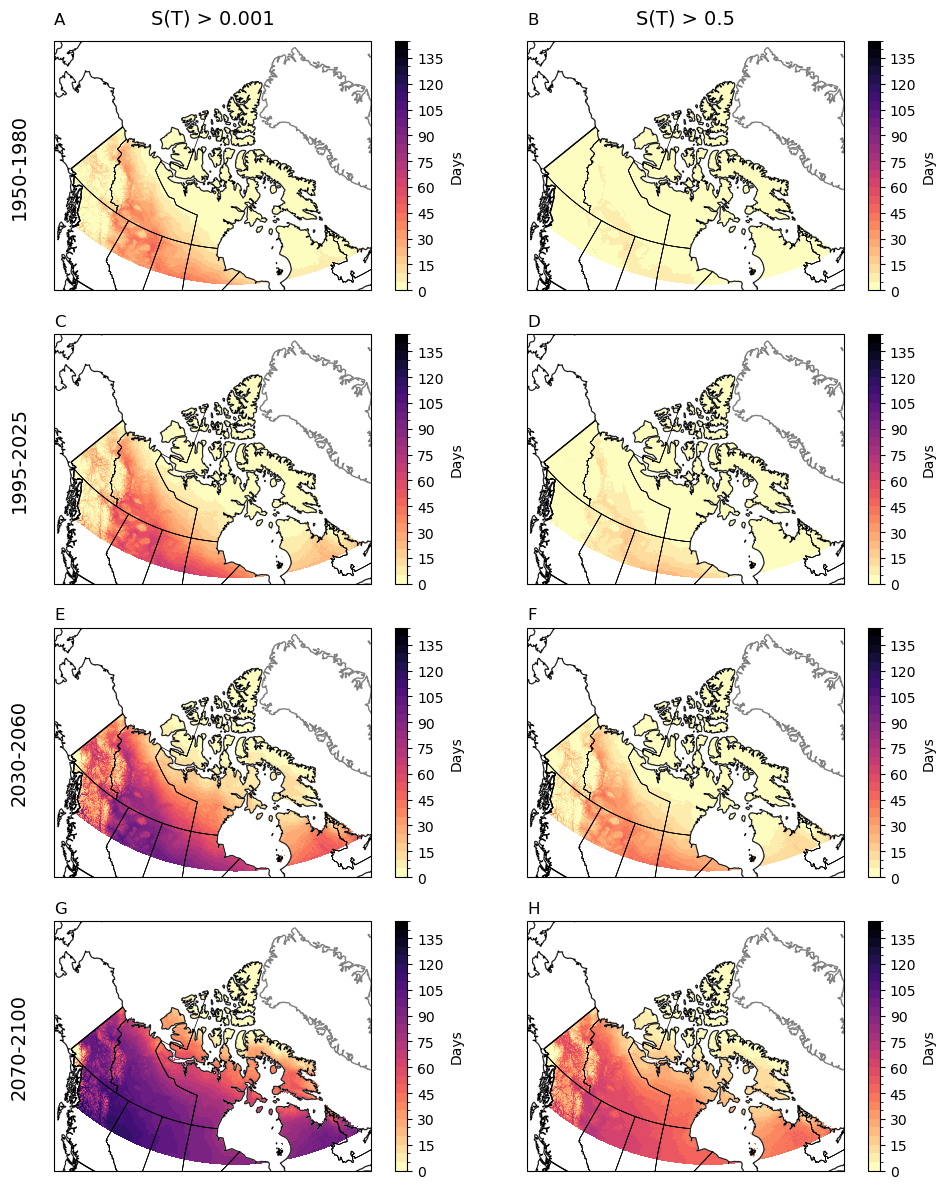

In [40]:
# plot all historical and future simulations
levels = np.arange(0, 150, 5)
cmap = 'magma_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 2, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980, S(T) > 0.001
ssp585_hist1_low["mean"].mean('time').plot.pcolormesh(ax = axes[0,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[0,0].set_title("A", loc='left')

# Historical 1: 1950-1980, S(T) > 0.5
ssp585_hist1_high["mean"].mean('time').plot.pcolormesh(ax = axes[0,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[0,1].set_title("B", loc='left')

# Historical 2: 1995-2025, S(T) > 0.001
ssp585_hist2_low["mean"].mean('time').plot.pcolormesh(ax = axes[1,0], 
                                                      transform = ccrs.PlateCarree(),
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                     )
axes[1,0].set_title("C", loc='left')


# Historical 2: 1995-2025, S(T) > 0.5
ssp585_hist2_high["mean"].mean('time').plot.pcolormesh(ax = axes[1,1], 
                                                       transform = ccrs.PlateCarree(),
                                                       levels = levels, 
                                                       cmap = cmap,
                                                       cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                      )
axes[1,1].set_title("D", loc='left')

# Future 1: 2030-2060, S(T) > 0.001
ssp585_future1_low["mean"].mean('time').plot.pcolormesh(ax = axes[2,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[2,0].set_title("E", loc='left')


# Future 1: 2030-2060, S(T) > 0.5
ssp585_future1_high["mean"].mean('time').plot.pcolormesh(ax = axes[2,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[2,1].set_title("F", loc='left')

# Future 2: 2070-2100, S(T) > 0.001
ssp585_future2_low["mean"].mean('time').plot.pcolormesh(ax = axes[3,0],
                                                        transform = ccrs.PlateCarree(),
                                                        levels = levels, 
                                                        cmap = cmap,
                                                        cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                       )
axes[3,0].set_title("G", loc='left')


# Future 2: 2070-2100, S(T) > 0.5
ssp585_future2_high["mean"].mean('time').plot.pcolormesh(ax = axes[3,1], 
                                                         transform = ccrs.PlateCarree(),
                                                         levels = levels, 
                                                         cmap = cmap,
                                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                        )
axes[3,1].set_title("H", loc='left')

for ax in axes.flat: # flat makes axes 1D instead of 2D
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())


# Column and row labels
cols = ["S(T) > 0.001", "S(T) > 0.5"]
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Column headers
for col, label in enumerate(cols):
    axes[0, col].set_title(label, fontsize=14, pad=12) # Add column 

# Row headers
for row, label in enumerate(rows):
    axes[row, 0].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row, 0].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/S_ssp585_lowerCI.png", dpi=300, bbox_inches="tight")

plt.show()

#### Cambridge Bay, Kugluktuk, and Yellowknife

In [49]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

In [50]:
## Cambridge Bay data
## 1950-1980
ssp585_hist1_low_CBAY = ssp585_hist1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp585_hist1_high_CBAY = ssp585_hist1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#1995-2025
ssp585_hist2_low_CBAY = ssp585_hist2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp585_hist2_high_CBAY = ssp585_hist2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2030-2060
ssp585_future1_low_CBAY = ssp585_future1_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp585_future1_high_CBAY = ssp585_future1_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

#2070-2100
ssp585_future2_low_CBAY = ssp585_future2_low.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")
ssp585_future2_high_CBAY = ssp585_future2_high.sel(lat = CBAY_lat, lon= CBAY_lon, method="nearest")

In [51]:
## Kugluktuk data
## 1950-1980
ssp585_hist1_low_KUG = ssp585_hist1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp585_hist1_high_KUG = ssp585_hist1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#1995-2025
ssp585_hist2_low_KUG = ssp585_hist2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp585_hist2_high_KUG = ssp585_hist2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2030-2060
ssp585_future1_low_KUG = ssp585_future1_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp585_future1_high_KUG = ssp585_future1_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

#2070-2100
ssp585_future2_low_KUG = ssp585_future2_low.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")
ssp585_future2_high_KUG = ssp585_future2_high.sel(lat = KUG_lat, lon= KUG_lon, method="nearest")

In [52]:
## Yellowknife data
## 1950-1980
ssp585_hist1_low_YKN = ssp585_hist1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp585_hist1_high_YKN = ssp585_hist1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#1995-2025
ssp585_hist2_low_YKN = ssp585_hist2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp585_hist2_high_YKN = ssp585_hist2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2030-2060
ssp585_future1_low_YKN = ssp585_future1_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp585_future1_high_YKN = ssp585_future1_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

#2070-2100
ssp585_future2_low_YKN = ssp585_future2_low.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")
ssp585_future2_high_YKN = ssp585_future2_high.sel(lat = YKN_lat, lon= YKN_lon, method="nearest")

In [53]:
# Create a summary table showing the mean number of days suitable for transmission

rows = [
    # Cambridge Bay
    ["Cambridge Bay", "S(T)>0.001",
     f"{ssp585_hist1_low_CBAY['mean'].mean('time').item():.1f} ({ssp585_hist1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_low_CBAY['mean'].mean('time').item():.1f} ({ssp585_hist2_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_future1_low_CBAY['mean'].mean('time').item():.1f} ({ssp585_future1_low_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_future2_low_CBAY['mean'].mean('time').item():.1f} ({ssp585_future2_low_CBAY['mean'].std('time').item():.1f})"],

    ["Cambridge Bay", "S(T)>0.5",
     f"{ssp585_hist1_high_CBAY['mean'].mean('time').item():.1f} ({ssp585_hist1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_high_CBAY['mean'].mean('time').item():.1f} ({ssp585_hist2_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_future1_high_CBAY['mean'].mean('time').item():.1f} ({ssp585_future1_high_CBAY['mean'].std('time').item():.1f})",
     f"{ssp585_future2_high_CBAY['mean'].mean('time').item():.1f} ({ssp585_future2_high_CBAY['mean'].std('time').item():.1f})"],

    # Kugluktuk
    ["Kugluktuk", "S(T)>0.001",
     f"{ssp585_hist1_low_KUG['mean'].mean('time').item():.1f} ({ssp585_hist1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_low_KUG['mean'].mean('time').item():.1f} ({ssp585_hist2_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_future1_low_KUG['mean'].mean('time').item():.1f} ({ssp585_future1_low_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_future2_low_KUG['mean'].mean('time').item():.1f} ({ssp585_future2_low_KUG['mean'].std('time').item():.1f})"],

    ["Kugluktuk", "S(T)>0.5",
     f"{ssp585_hist1_high_KUG['mean'].mean('time').item():.1f} ({ssp585_hist1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_high_KUG['mean'].mean('time').item():.1f} ({ssp585_hist2_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_future1_high_KUG['mean'].mean('time').item():.1f} ({ssp585_future1_high_KUG['mean'].std('time').item():.1f})",
     f"{ssp585_future2_high_KUG['mean'].mean('time').item():.1f} ({ssp585_future2_high_KUG['mean'].std('time').item():.1f})"],

    # Yellowknife
    ["Yellowknife", "S(T)>0.001",
     f"{ssp585_hist1_low_YKN['mean'].mean('time').item():.1f} ({ssp585_hist1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_low_YKN['mean'].mean('time').item():.1f} ({ssp585_hist2_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_future1_low_YKN['mean'].mean('time').item():.1f} ({ssp585_future1_low_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_future2_low_YKN['mean'].mean('time').item():.1f} ({ssp585_future2_low_YKN['mean'].std('time').item():.1f})"],

    ["Yellowknife", "S(T)>0.5",
     f"{ssp585_hist1_high_YKN['mean'].mean('time').item():.1f} ({ssp585_hist1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_hist2_high_YKN['mean'].mean('time').item():.1f} ({ssp585_hist2_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_future1_high_YKN['mean'].mean('time').item():.1f} ({ssp585_future1_high_YKN['mean'].std('time').item():.1f})",
     f"{ssp585_future2_high_YKN['mean'].mean('time').item():.1f} ({ssp585_future2_high_YKN['mean'].std('time').item():.1f})"],
]

df_ssp585 = pd.DataFrame(
    rows,
    columns=[
        "Location", "Suitability threshold",
        "1950–1980", "1995–2025",
        "2030–2060", "2070–2100"
    ]
)

In [54]:
df_ssp585

,Location,Suitability threshold,1950–1980,1995–2025,2030–2060,2070–2100
0,Cambridge Bay,S(T)>0.001,0.4 (1.2),2.6 (4.4),11.5 (10.1),53.3 (11.7)
1,Cambridge Bay,S(T)>0.5,0.0 (0.0),0.1 (0.4),1.6 (4.0),20.5 (10.8)
2,Kugluktuk,S(T)>0.001,4.1 (4.1),9.7 (8.6),23.5 (14.7),64.2 (13.0)
3,Kugluktuk,S(T)>0.5,0.4 (1.3),1.3 (1.9),6.1 (6.2),23.8 (9.0)
4,Yellowknife,S(T)>0.001,29.5 (9.6),44.0 (17.2),77.3 (13.4),95.9 (13.5)
5,Yellowknife,S(T)>0.5,4.7 (5.0),9.7 (8.8),32.6 (12.1),57.5 (12.7)


In [55]:
df_ssp585.to_csv("data-processed/S.ssp585.locations.meandays.csv", index=False)